# Libraries

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider
import os
import pandas as pd
import json
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
import math

# Extraction of parameters from file

In [2]:
H_E=[1, 2]
Patient=[1, 3]
expansion=[3, 3.5, 4]

dir=os.getcwd()
full_path_dir=os.path.join(dir, "Qupath_project", "text_data")

for pat_id in Patient:
    cell_area_pat=0
    cell_max_cal_pat=0
    cell_min_cal_pat=0
    r2D_pat=0
    r3D_pat=0
    den=0
    for he in H_E:
        for coef in expansion:
            text_file=f"Patient_{pat_id}_H&E_{he}_exp_{coef}.txt"
            file_path=os.path.join(full_path_dir, text_file)
            if not os.path.exists(file_path):
                print(f"No file named {text_file} in {full_path_dir}")
                continue
            den+=1
            df = pd.read_csv(file_path, sep='\t', engine='python')
            cell_area=df["Cell: Area"].to_numpy()
            cell_max_cal=df["Cell: Max caliper"].to_numpy()
            cell_min_cal=df["Cell: Min caliper"].to_numpy()

            # Plot histograms for cell area, max caliper, and min caliper
            '''
            plt.figure(figsize=(15, 4))

            plt.subplot(1, 3, 1)
            plt.hist(cell_area, bins=30, color='skyblue', edgecolor='black')
            plt.title(f"Cell Area patient {pat_id} H&E {he} cell expansion of {coef} µm")
            plt.xlabel("µm²")
            plt.ylabel("Number of cells")

            plt.subplot(1, 3, 2)
            plt.hist(cell_max_cal, bins=30, color='lightgreen', edgecolor='black')
            plt.title(f"Cell Max Caliper patient {pat_id} H&E {he} cell expansion of {coef} µm")
            plt.xlabel("µm")

            plt.subplot(1, 3, 3)
            plt.hist(cell_min_cal, bins=30, color='salmon', edgecolor='black')
            plt.title(f"Cell Min Caliper patient {pat_id} H&E {he} cell expansion of {coef} µm")
            plt.xlabel("µm")

            plt.tight_layout()
            plt.show()
            '''

            mean_cell_area=np.mean(cell_area)
            mean_cell_max_cal=np.mean(cell_max_cal)
            mean_cell_min_cal=np.mean(cell_min_cal)

            std_cell_area=np.std(cell_area)
            std_cell_max_cal=np.std(cell_max_cal)
            std_cell_min_cal=np.std(cell_min_cal)

            r2D=np.sqrt(mean_cell_min_cal*mean_cell_max_cal/4)
            std_r2D = 0.25 * np.sqrt((mean_cell_max_cal / mean_cell_min_cal) * std_cell_min_cal**2+ (mean_cell_min_cal / mean_cell_max_cal) * std_cell_max_cal**2)
            r3D=1.27*r2D
            std_r3D=1.27*std_r2D

            print("---------Statistics---------")
            print(f"Mean cell area = {mean_cell_area:.2f} µm²")
            print(f"Mean max caliper = {mean_cell_max_cal:.2f} µm")
            print(f"Mean min caliper = {mean_cell_min_cal:.2f} µm")
            print(f"Equivalent average 2D radius {r2D:.2f} µm and 2D standard deviation {std_r2D:.2f} µm")
            print(f"Equivalent average 3D radius: {r3D:.2f} µm and 3D standard deviation {std_r3D:.2f} µm")

            cell_area_pat+=mean_cell_area
            cell_max_cal_pat+=mean_cell_max_cal
            cell_min_cal_pat+=mean_cell_min_cal
            r2D_pat+=r2D
            r3D_pat+=r3D


    cell_area_pat=cell_area_pat/den
    cell_max_cal_pat=cell_max_cal_pat/den
    cell_min_cal_pat=cell_min_cal_pat/den
    r2D_pat=r2D_pat/den
    r3D_pat=r3D_pat/den

    print(f"---------Statistics {pat_id}---------")
    print(f"Mean cell area = {cell_area_pat:.2f} µm²")
    print(f"Mean max caliper = {cell_max_cal_pat:.2f} µm")
    print(f"Mean min caliper = {cell_min_cal_pat:.2f} µm")
    print(f"Equivalent average 2D radius {r2D_pat:.2f} µm")
    print(f"Equivalent average 3D radius: {r3D_pat:.2f} µm")




---------Statistics---------
Mean cell area = 85.68 µm²
Mean max caliper = 12.14 µm
Mean min caliper = 9.14 µm
Equivalent average 2D radius 5.27 µm and 2D standard deviation 0.67 µm
Equivalent average 3D radius: 6.69 µm and 3D standard deviation 0.85 µm
---------Statistics---------
Mean cell area = 90.39 µm²
Mean max caliper = 12.54 µm
Mean min caliper = 9.37 µm
Equivalent average 2D radius 5.42 µm and 2D standard deviation 0.70 µm
Equivalent average 3D radius: 6.88 µm and 3D standard deviation 0.89 µm
---------Statistics---------
Mean cell area = 95.39 µm²
Mean max caliper = 12.97 µm
Mean min caliper = 9.59 µm
Equivalent average 2D radius 5.58 µm and 2D standard deviation 0.75 µm
Equivalent average 3D radius: 7.08 µm and 3D standard deviation 0.95 µm
---------Statistics---------
Mean cell area = 104.77 µm²
Mean max caliper = 13.14 µm
Mean min caliper = 10.21 µm
Equivalent average 2D radius 5.79 µm and 2D standard deviation 0.71 µm
Equivalent average 3D radius: 7.36 µm and 3D standard 

# STD

In [3]:
H_E=[1, 2]
Patient=[1, 3]
expansion=[3, 3.5, 4]

dir=os.getcwd()
full_path_dir=os.path.join(dir, "Qupath_project", "text_data")

for pat_id in Patient:
    all_cell_area = []
    all_cell_max_cal = []
    all_cell_min_cal = []

    for he in H_E:
        for coef in expansion:
            text_file=f"Patient_{pat_id}_H&E_{he}_exp_{coef}.txt"
            file_path=os.path.join(full_path_dir, text_file)

            if not os.path.exists(file_path):
                continue

            df = pd.read_csv(file_path, sep='\t', engine='python')

            all_cell_area.extend(df["Cell: Area"].to_numpy())
            all_cell_max_cal.extend(df["Cell: Max caliper"].to_numpy())
            all_cell_min_cal.extend(df["Cell: Min caliper"].to_numpy())

    all_cell_area = np.array(all_cell_area)
    all_cell_max_cal = np.array(all_cell_max_cal)
    all_cell_min_cal = np.array(all_cell_min_cal)

    mean_cell_area_pat = np.mean(all_cell_area)
    std_cell_area_pat  = np.std(all_cell_area, ddof=1)

    mean_cell_max_cal_pat = np.mean(all_cell_max_cal)
    std_cell_max_cal_pat  = np.std(all_cell_max_cal, ddof=1)

    mean_cell_min_cal_pat = np.mean(all_cell_min_cal)
    std_cell_min_cal_pat  = np.std(all_cell_min_cal, ddof=1)

    r2D_pat = np.sqrt(mean_cell_min_cal_pat * mean_cell_max_cal_pat / 4)

    std_r2D_pat = 0.25 * np.sqrt(
        (mean_cell_max_cal_pat / mean_cell_min_cal_pat) * std_cell_min_cal_pat**2 +
        (mean_cell_min_cal_pat / mean_cell_max_cal_pat) * std_cell_max_cal_pat**2
    )

    r3D_pat = 1.27 * r2D_pat
    std_r3D_pat = 1.27 * std_r2D_pat

    print(f"==== PATIENT STATISTICS {pat_id} ====")
    print(f"Mean area : {mean_cell_area_pat:.2f} ± {std_cell_area_pat:.2f} µm²")
    print(f"Mean max caliper : {mean_cell_max_cal_pat:.2f} ± {std_cell_max_cal_pat:.2f} µm")
    print(f"Mean min caliper : {mean_cell_min_cal_pat:.2f} ± {std_cell_min_cal_pat:.2f} µm")
    print(f"Radius 2D : {r2D_pat:.2f} ± {std_r2D_pat:.2f} µm")
    print(f"Radius 3D : {r3D_pat:.2f} ± {std_r3D_pat:.2f} µm")

==== PATIENT STATISTICS 1 ====
Mean area : 111.43 ± 39.92 µm²
Mean max caliper : 13.61 ± 2.43 µm
Mean min caliper : 10.47 ± 2.08 µm
Radius 2D : 5.97 ± 0.80 µm
Radius 3D : 7.58 ± 1.01 µm
==== PATIENT STATISTICS 3 ====
Mean area : 92.00 ± 31.27 µm²
Mean max caliper : 12.94 ± 2.30 µm
Mean min caliper : 9.32 ± 1.81 µm
Radius 2D : 5.49 ± 0.72 µm
Radius 3D : 6.97 ± 0.92 µm


# Generation of the JSON file with the parameters for each ROI

In [4]:
if not os.path.exists("roi_results.json"):
    H_E = [1, 2]
    Patient = [1, 3]
    expansion = [3, 3.5, 4]

    allowed_ROI = {"ROI1", "ROI2", "ROI3", "ROI4"}

    results_json = {}

    dir = os.getcwd()
    full_path_dir = os.path.join(dir, "Qupath_project", "text_data")

    for pat_id in Patient:

        results_json[f"Patient_{pat_id}"] = {}

        for he in H_E:
            results_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}

            for coef in expansion:

                results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{coef}"] = {}

                text_file = f"Patient_{pat_id}_H&E_{he}_exp_{coef}.txt"
                file_path = os.path.join(full_path_dir, text_file)

                if not os.path.exists(file_path):
                    continue

                df = pd.read_csv(file_path, sep='\t', engine='python')

                df = df[df["Parent"].isin(allowed_ROI)]

                for roi in sorted(df["Parent"].unique()):

                    df_roi = df[df["Parent"] == roi]

                    area = df_roi["Cell: Area"].to_numpy()
                    max_cal = df_roi["Cell: Max caliper"].to_numpy()
                    min_cal = df_roi["Cell: Min caliper"].to_numpy()

                    mean_area = np.mean(area)
                    std_area = np.std(area, ddof=1)

                    mean_max = np.mean(max_cal)
                    std_max = np.std(max_cal, ddof=1)

                    mean_min = np.mean(min_cal)
                    std_min = np.std(min_cal, ddof=1)

                    r2D = np.sqrt(mean_min * mean_max / 4)

                    std_r2D = 0.25 * np.sqrt(
                        (mean_max / mean_min) * std_min**2 +
                        (mean_min / mean_max) * std_max**2
                    )

                    # Correction factor for 3D radius
                    r3D = 1.27 * r2D
                    std_r3D = 1.27 * std_r2D

                    results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{coef}"][roi] = {
                        "mean_area": mean_area,
                        "std_area": std_area,
                        "mean_max_caliper": mean_max,
                        "std_max_caliper": std_max,
                        "mean_min_caliper": mean_min,
                        "std_min_caliper": std_min,
                        "mean_r2D": r2D,
                        "std_r2D": std_r2D,
                        "mean_r3D": r3D,
                        "std_r3D": std_r3D
                    }

    # Saving results
    with open("roi_results.json", "w") as f:
        json.dump(results_json, f, indent=4)

    print("JSON generated : roi_results.json")

else:
    with open("roi_results.json", 'r', encoding='utf-8') as f:
        results_json = json.load(f)

    print("ROI results loaded from roi_results.json")

ROI results loaded from roi_results.json


# Cell density with Abercrombie

In [5]:
if not os.path.exists("density_results.json"):
    slice_width=4 #4 um

    density_json={}

    for pat_id in Patient:
        print(f"----------Statistics for patient {pat_id}----------")
        density_json[f"Patient_{pat_id}"] = {}
        for he in H_E:
            print(f"=== H&E {he} ===")
            density_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}
            for exp in expansion:
                density_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"]={}
                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    print(f"No file named {annot_file} in {full_path_dir}")
                    continue

                df_annot = pd.read_csv(annot_path, sep='\t', engine='python')

                # ROIs data
                df_annot_sorted = df_annot.sort_values(by="Name")
                names = df_annot_sorted["Name"].to_numpy()
                areas = df_annot_sorted["Area µm^2"].to_numpy()
                
                # Cell data
                patient_file = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
                patient_path = os.path.join(full_path_dir, patient_file)
                if not os.path.exists(patient_path):
                    print(f"No file named {patient_file} in {full_path_dir}")
                    continue

                df_patient = pd.read_csv(patient_path, sep='\t', engine='python')

                # Quantity calculations
                preliminary_file = "roi_results.json"
                with open(preliminary_file, 'r', encoding='utf-8') as f:
                    preliminary_results=json.load(f)

                for i in range(len(names)):
                    roi_name = names[i]
                    df_roi = df_patient[df_patient["Parent"] == roi_name]
                    cells_area = df_roi["Cell: Area"].to_numpy()
                    if len(cells_area) == 0:
                        print(f"ROI {roi_name} (H&E {he}, exp {exp}) : no cell found")
                        continue

                    density_2d = sum(cells_area) / areas[i]

                    n = len(df_roi)
                    r2D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["mean_r2D"]
                    sigma_r2D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["std_r2D"]

                    r3D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["mean_r3D"]
                    sigma_r3D = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["std_r3D"]

                    # N_v et V_cell
                    N_v = n / ((slice_width + 2*r2D) * areas[i])
                    V_cell = 4*np.pi*(r3D**3)/3
                    density_3d = N_v * V_cell

                    # Uncertainty propagation
                    dN_dr2D = -2 * n / ((slice_width + 2*r2D)**2 * areas[i])
                    dV_dr3D = 4 * np.pi * (r3D**2)

                    sigma_Nv = abs(dN_dr2D) * sigma_r2D
                    sigma_Vcell = abs(dV_dr3D) * sigma_r3D

                    sigma_density3D = np.sqrt((sigma_Nv * V_cell)**2 + (N_v * sigma_Vcell)**2)

                    density_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name] = {
                        "density_2d": round(density_2d, 2),
                        "density_3d": round(density_3d, 2),
                        "sigma_density_3d": round(sigma_density3D, 2)
                    }

                    print(f"{roi_name:<20} | 3D density: {density_3d:>10.2f} ± {sigma_density3D:>6.2f} | 2D density: {density_2d:>10.2f} | Expansion: {exp}")


    # Saving results JSON
    with open("density_results.json", "w") as f:
        json.dump(density_json, f, indent=4)

    print("JSON generated : density_results.json")

else:
    with open("density_results.json", 'r', encoding='utf-8') as f:
        density_json = json.load(f)

    print("Density results loaded from density_results.json")

Density results loaded from density_results.json


# Load the LUT

In [6]:
lut = loadmat('lookup_table_validation_compat.mat') #put the new LUT name
params_lut = lut['params']     
signals_lut = lut['signals_4D']            
sequence_lut = lut['sequence']

params_lut = np.array(params_lut) 
signals_lut = np.array(signals_lut)

# Checking LUT

In [7]:
bval = np.array(sequence_lut['bval'][0][0]).flatten()   # shape: (n_bval,)
TD   = np.array(sequence_lut['TD'][0][0]).flatten()     # shape: (n_del,)
bvecs = np.array(sequence_lut['bvecs'][0][0])           # shape: (n_bvec, 3)
print("params shape:", params_lut.shape)
print("signals shape:", signals_lut.shape)
print("bval:", bval)
print("TD:", TD[:5])
print("bvecs shape:", bvecs.shape)

params shape: (1034, 4)
signals shape: (1034, 2, 16, 64)
bval: [ 0.05  0.2   0.35  0.8   0.95  1.5   2.3   2.4   3.45  4.25  4.75  6.
  6.75  9.85 13.5  18.8 ]
TD: [19. 49.]
bvecs shape: (64, 3)


# Delaunay interpolation

In [8]:
def interpolate_signal(f, Dex, rmean, rsd, bval, TD, tri, signals_lookup, params_lut):
    # Security check for zero density
    if f < 0.007:
        return 1.0

    query_params = np.array([f, Dex, rmean, rsd])
    
    # Get indices for TD and bval (ensure sequence_lut is accessible)
    bvals = sequence_lut['bval'][0][0]
    TDs = sequence_lut['TD'][0][0]
    TD_index = np.where(TDs == TD)[0][0]
    bval_index = np.where(bvals == bval)[0][0]

    # Find the simplex containing the query point
    simplex_index = tri.find_simplex(query_params)

    # OUT OF HULL : Fallback on nearest neighbor
    if simplex_index == -1:
        distances = np.linalg.norm(params_lut - query_params, axis=1)
        nearest_idx = np.argmin(distances)
        signal_nearest = signals_lookup[nearest_idx]
        return np.mean(signal_nearest[TD_index, bval_index, :]) / 1e5

    # IN HULL : Barycentric interpolation
    vertex_index = tri.simplices[simplex_index]
    vertices = params_lut[vertex_index]

    try:
        T = vertices[1:] - vertices[0]
        v = query_params - vertices[0]
        bary_coords = np.linalg.solve(T.T, v)
        bary_coords = np.append(1 - np.sum(bary_coords), bary_coords)
        
        signals_subset = signals_lookup[vertex_index]
        interpolated_signal = np.tensordot(bary_coords, signals_subset, axes=(0, 0))
        return np.mean(interpolated_signal[TD_index, bval_index, :]) / 1e5
    except:
        # Fallback to nearest neighbor in case of numerical issues
        distances = np.linalg.norm(vertices - query_params, axis=1)
        nearest_v_idx = vertex_index[np.argmin(distances)]
        return np.mean(signals_lookup[nearest_v_idx][TD_index, bval_index, :]) / 1e5

# Dex inference via chi² grid

In [42]:
def get_signal_curve_lut(f, Dex, rmean, rsd, TD, tri, signals_lookup, params_lut):
    """
    Return the predicted signal at ALL LUT b-values for a given (f, Dex, rmean, rsd, TD).
    Used to allow b-value interpolation when DWI and LUT b-grids don't match.

    Returns
    -------
    bvals_lut : 1-D array, LUT b-values in ms/µm²
    signals   : 1-D array, predicted S/S0 at each LUT b-value
    """
    bvals_lut = np.array(sequence_lut['bval'][0][0]).flatten()
    TDs       = np.array(sequence_lut['TD'][0][0]).flatten()
    TD_index  = np.where(TDs == TD)[0][0]

    if f < 0.007:
        return bvals_lut, np.ones(len(bvals_lut))

    query_params  = np.array([f, Dex, rmean, rsd])
    simplex_index = tri.find_simplex(query_params)

    if simplex_index == -1:
        # Nearest-neighbour fallback
        nearest_idx = np.argmin(np.linalg.norm(params_lut - query_params, axis=1))
        signals = np.mean(signals_lookup[nearest_idx][TD_index, :, :], axis=-1) / 1e5
    else:
        vertex_index = tri.simplices[simplex_index]
        vertices     = params_lut[vertex_index]
        try:
            T = vertices[1:] - vertices[0]
            v = query_params - vertices[0]
            bary_coords = np.linalg.solve(T.T, v)
            bary_coords = np.append(1 - np.sum(bary_coords), bary_coords)
            interpolated = np.tensordot(bary_coords, signals_lookup[vertex_index], axes=(0, 0))
            signals = np.mean(interpolated[TD_index, :, :], axis=-1) / 1e5
        except Exception:
            nearest_v_idx = vertex_index[np.argmin(np.linalg.norm(vertices - query_params, axis=1))]
            signals = np.mean(signals_lookup[nearest_v_idx][TD_index, :, :], axis=-1) / 1e5

    return bvals_lut, signals

def infer_dex_chi2(df_dwi, cell_areas, max_calipers, min_calipers, roi_area_um2,
                   Dex_grid, TD, tri, signals_lut, params_lut,
                   slice_width_um=4, bval_max_um2=7.5):
    """
    Infer Dex by chi² minimisation on a grid.

    The LUT and DWI b-values do not need to match: the LUT signal curve is
    interpolated (np.interp, log-linear) to the DWI b-values automatically.
    DWI points outside the LUT b-value range are discarded with a warning.

    Parameters
    ----------
    df_dwi        : DataFrame ['b_value' (s/mm²), 'signal', 'noise', 'TD']
                    as returned by extract_patient_curves
    cell_areas, max_calipers, min_calipers : QuPath cell arrays for one ROI
    roi_area_um2  : ROI area in µm²
    Dex_grid      : 1-D array of Dex candidates (µm²/ms)
    TD            : diffusion time in ms (19 or 49)
    tri           : Delaunay triangulation of params_lut
    signals_lut, params_lut : LUT arrays
    slice_width_um : histological slice thickness (default 4 µm)
    bval_max_um2  : max b-value to use, in ms/µm² (default 7.5)

    Returns
    -------
    dict with keys:
        Dex_best, Dex_ci_low, Dex_ci_high  – inferred value and 68% CI (Δχ²=1)
        chi2_grid, Dex_grid                 – full chi² profile
        chi2_min, f_mean, r3D_mean, r3D_std – intermediate quantities
        bvals_used                           – DWI b-values actually used (ms/µm²)
    """
    # --- 1. Histological point estimate (f, r) ---
    mean_max = np.mean(max_calipers)
    mean_min = np.mean(min_calipers)
    std_max  = np.std(max_calipers, ddof=1)
    std_min  = np.std(min_calipers, ddof=1)

    r2D     = np.sqrt(mean_max * mean_min / 4)
    std_r2D = 0.25 * np.sqrt(
        (mean_max / mean_min) * std_min**2 +
        (mean_min / mean_max) * std_max**2
    )
    r3D     = 1.27 * r2D
    std_r3D = 1.27 * std_r2D

    n_cells = len(cell_areas)
    N_v     = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
    f_mean  = N_v * (4/3) * np.pi * r3D**3

    # --- 2. Measured DWI points for this TD ---
    bvals_lut_um2 = np.array(sequence_lut['bval'][0][0]).flatten()
    bval_lut_min, bval_lut_max = bvals_lut_um2.min(), bvals_lut_um2.max()

    td_str = f"{TD}ms"
    df_td  = (df_dwi[df_dwi["TD"] == td_str]
              .copy()
              .assign(bval_um2=lambda d: d["b_value"] / 1000)
              .query("bval_um2 > 0 and bval_um2 <= @bval_max_um2")
              .sort_values("bval_um2"))

    # Discard DWI points outside the LUT b-value range
    out_of_range = df_td["bval_um2"] < bval_lut_min
    if out_of_range.any():
        print(f"[infer_dex_chi2] Warning: {out_of_range.sum()} DWI b-value(s) below LUT "
              f"range [{bval_lut_min:.3f}, {bval_lut_max:.3f}] ms/µm² — discarded.")
        df_td = df_td[~out_of_range]

    bvals_um2 = df_td["bval_um2"].to_numpy()
    S_meas    = df_td["signal"].to_numpy()
    sigma     = df_td["noise"].to_numpy()
    sigma     = np.where(sigma < 1e-6, 1e-6, sigma)

    if len(bvals_um2) == 0:
        raise ValueError("No usable DWI b-values after filtering — check bval_max_um2 and LUT range.")

    # --- 3. Chi² profile (with LUT → DWI b-value interpolation) ---
    chi2_vals = np.zeros(len(Dex_grid))
    for k, Dex in enumerate(Dex_grid):
        bvals_curve, sig_curve = get_signal_curve_lut(
            f_mean, Dex, r3D, std_r3D, TD, tri, signals_lut, params_lut)
        # Log-linear interpolation for smoother decay curves
        log_sig_curve = np.log(np.clip(sig_curve, 1e-10, None))
        log_S_pred    = np.interp(bvals_um2, bvals_curve, log_sig_curve)
        S_pred        = np.exp(log_S_pred)
        chi2_vals[k]  = np.sum(((S_meas - S_pred) / sigma) ** 2)

    # --- 4. Best estimate and 68% CI (Δχ² = 1, one free parameter) ---
    best_idx  = np.argmin(chi2_vals)
    chi2_min  = chi2_vals[best_idx]
    Dex_best  = Dex_grid[best_idx]

    within_ci   = Dex_grid[chi2_vals <= chi2_min + 1.0]
    Dex_ci_low  = float(within_ci[0])  if len(within_ci) else float(Dex_best)
    Dex_ci_high = float(within_ci[-1]) if len(within_ci) else float(Dex_best)

    return {
        "Dex_best":    float(Dex_best),
        "Dex_ci_low":  Dex_ci_low,
        "Dex_ci_high": Dex_ci_high,
        "chi2_grid":   chi2_vals.tolist(),
        "Dex_grid":    Dex_grid.tolist(),
        "chi2_min":    float(chi2_min),
        "f_mean":      float(f_mean),
        "r3D_mean":    float(r3D),
        "r3D_std":     float(std_r3D),
        "bvals_used":  bvals_um2.tolist(),
    }

def plot_dex_inference(result, ax=None, title=""):
    """Display the chi² profile with the best Dex and its 68% CI."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))

    Dex_grid    = np.array(result["Dex_grid"])
    chi2        = np.array(result["chi2_grid"])
    chi2_min    = result["chi2_min"]
    Dex_best    = result["Dex_best"]
    Dex_ci_low  = result["Dex_ci_low"]
    Dex_ci_high = result["Dex_ci_high"]

    ax.plot(Dex_grid, chi2, "k-", linewidth=1.5, label=r"$\chi^2(D_{ex})$")
    ax.axhline(chi2_min + 1, color="gray", linestyle="--", alpha=0.7,
               label=r"$\chi^2_{\min} + 1$")
    ax.axvline(Dex_best, color="tab:red", linestyle="-",
               label=f"$D_{{ex}}^*$ = {Dex_best:.2f} µm²/ms")
    ax.axvspan(Dex_ci_low, Dex_ci_high, alpha=0.15, color="tab:red",
               label=f"CI 68% [{Dex_ci_low:.2f}, {Dex_ci_high:.2f}] µm²/ms")

    ax.set_xlabel(r"$D_{ex}$ (µm²/ms)")
    ax.set_ylabel(r"$\chi^2$")
    ax.set_title(title or "Dex inference — chi² grid")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    return ax

In [19]:
# ── Load DWI data (mirrored from combined.ipynb) ────────────────────────────

def extract_patient_curves(data_dict, slice_idx, center, roi_size, roi_type='square'):
    """Extraction of the DWI curves for a given patient and slice, with noise envelope."""
    full_brain  = np.transpose(data_dict["fullbrain_all"], (0, 2, 1, 3))
    signal_slice = full_brain[:, :, slice_idx, :]

    noise_data  = np.transpose(data_dict["noisemap_all"], (0, 2, 1, 3))
    noise_slice = noise_data[:, :, slice_idx, :]

    H, W, num_b_volumes = signal_slice.shape

    b_values     = data_dict["bv_all"].flatten()
    zero_idx     = np.where(b_values == 0)[0]
    split_points = np.concatenate(([-1], zero_idx, [len(b_values)]))

    blocks = []
    for i in range(len(split_points) - 1):
        block = b_values[split_points[i] + 1 : split_points[i + 1]]
        if len(block) > 0:
            blocks.append(block)

    final_bvalues = [b for block in blocks for b in block]
    ind_mid       = len(blocks[0]) + len(blocks[1])

    Y, X = np.ogrid[:H, :W]
    if roi_type == 'square':
        mask = (
            (Y >= center[0] - roi_size) & (Y <= center[0] + roi_size) &
            (X >= center[1] - roi_size) & (X <= center[1] + roi_size)
        )
    else:
        mask = np.sqrt((Y - center[0])**2 + (X - center[1])**2) <= roi_size

    noise_factor = 1 / np.sqrt(32)
    mean_signals, std_signals, mean_noise = [], [], []
    for i in range(num_b_volumes):
        mean_signals.append(np.nanmean(signal_slice[:, :, i][mask]))
        std_signals.append(np.nanstd(signal_slice[:, :, i][mask]))
        mean_noise.append(np.nanmean(noise_slice[:, :, i][mask]) * noise_factor)

    df = pd.DataFrame({
        'b_value': final_bvalues,
        'signal':  mean_signals,
        'std':     std_signals,
        'noise':   mean_noise,
    })
    df['TD'] = '49ms'
    df.iloc[:ind_mid, df.columns.get_loc('TD')] = '19ms'
    return df


# Load .mat files
from scipy.io import loadmat as _loadmat
data_p1 = _loadmat("./Patient_1/Combined/CON_0101SP_12072016_tumor_all.mat")
data_p3 = _loadmat("./Patient_3/Combined/CON_03_V01_tumor_all.mat")

# Extract DWI curves (same ROI centres as combined.ipynb)
df_p1 = extract_patient_curves(data_p1, slice_idx=36, center=(49, 49), roi_size=3, roi_type='square')
df_p3 = extract_patient_curves(data_p3, slice_idx=31, center=(73, 28), roi_size=3, roi_type='square')

print("df_p1:", df_p1.shape, "| TDs:", df_p1['TD'].unique())
print("df_p3:", df_p3.shape, "| TDs:", df_p3['TD'].unique())

df_p1: (13, 5) | TDs: ['19ms' '49ms']
df_p3: (12, 5) | TDs: ['19ms' '49ms']


Dex_best  = 2.853 µm²/ms
CI 68%    = [2.841, 2.853] µm²/ms
f_mean    = 0.4823
r3D_mean  = 7.94 µm


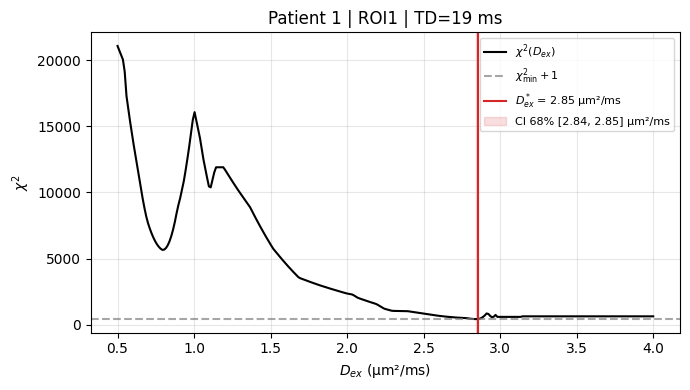

In [24]:
# ── Run Dex inference on one ROI ────────────────────────────────────────────

tri      = Delaunay(params_lut)
Dex_grid = np.linspace(1.0, 3.5, 300)

# Parameters to change as needed
pat_id   = 3
he       = 1
exp      = 4
roi_name = "ROI3"
TD_val   = 19
df_dwi   = df_p3    # df_p1 for Patient 1, df_p3 for Patient 3

cell_file  = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
df_cells   = pd.read_csv(os.path.join(full_path_dir, cell_file),  sep='\t', engine='python')
df_annot   = pd.read_csv(os.path.join(full_path_dir, annot_file), sep='\t', engine='python')

df_roi       = df_cells[df_cells["Parent"] == roi_name]
roi_area_um2 = df_annot.loc[df_annot["Name"] == roi_name, "Area µm^2"].values[0]

result = infer_dex_chi2(
    df_dwi       = df_dwi,
    cell_areas   = df_roi["Cell: Area"].to_numpy(),
    max_calipers = df_roi["Cell: Max caliper"].to_numpy(),
    min_calipers = df_roi["Cell: Min caliper"].to_numpy(),
    roi_area_um2 = roi_area_um2,
    Dex_grid     = Dex_grid,
    TD           = TD_val,
    tri          = tri,
    signals_lut  = signals_lut,
    params_lut   = params_lut,
)

print(f"Dex_best  = {result['Dex_best']:.3f} µm²/ms")
print(f"CI 68%    = [{result['Dex_ci_low']:.3f}, {result['Dex_ci_high']:.3f}] µm²/ms")
print(f"f_mean    = {result['f_mean']:.4f}")
print(f"r3D_mean  = {result['r3D_mean']:.2f} µm")

plot_dex_inference(result, title=f"Patient {pat_id} | {roi_name} | TD={TD_val} ms")
plt.tight_layout()
plt.show()

# Infer Dex shrinkage

In [21]:
def infer_Dex_shrinkage_chi2(df_dwi, cell_areas, max_calipers, min_calipers,
                              roi_area_um2, TD, tri, signals_lut, params_lut,
                              slice_width_um=4, bval_max_um2=7.5,
                              Dex_grid=None, k_grid=None):
    """
    Joint inference of Dex and the shrinkage factor k via a 2D chi² grid.

    Histological shrinkage tends to overestimate the cell density f.
    Correction: f_corrected = f_raw * k   (k ∈ ]0, 1]).

    The LUT signal is log-linearly interpolated to DWI b-values,
    so no exact grid matching is required.

    Parameters
    ----------
    df_dwi          : DataFrame ['b_value' (s/mm²), 'signal', 'noise', 'TD']
    cell_areas, max_calipers, min_calipers : QuPath arrays for one ROI
    roi_area_um2    : ROI area in µm²
    TD              : diffusion time in ms (19 or 49)
    slice_width_um  : slice thickness (µm, default 4)
    bval_max_um2    : max b-value used (ms/µm², default 7.5)
    Dex_grid        : Dex grid (µm²/ms), default linspace(0.5, 3.5, 60)
    k_grid          : shrinkage grid, default linspace(0.3, 1.0, 30)

    Returns
    -------
    dict with: Dex_best, k_best, Dex_ci, k_ci (tuples), chi2_map,
               Dex_grid, k_grid, f_raw, r3D_mean, r3D_std
    """
    from scipy.stats import chi2 as chi2_dist

    if Dex_grid is None:
        Dex_grid = np.linspace(0.5, 3.5, 60)
    if k_grid is None:
        k_grid = np.linspace(0.1, 1.0, 30)

    # --- 1. Histology: raw parameters (without shrinkage correction) ---
    mean_max = np.mean(max_calipers)
    mean_min = np.mean(min_calipers)
    std_max  = np.std(max_calipers, ddof=1)
    std_min  = np.std(min_calipers, ddof=1)

    r2D     = np.sqrt(mean_max * mean_min / 4)
    std_r2D = 0.25 * np.sqrt(
        (mean_max / mean_min) * std_min**2 +
        (mean_min / mean_max) * std_max**2
    )
    r3D     = 1.27 * r2D
    std_r3D = 1.27 * std_r2D

    n_cells = len(cell_areas)
    N_v     = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
    f_raw   = N_v * (4/3) * np.pi * r3D**3   # raw density, before k correction

    # --- 2. Measured DWI for this TD ---
    bvals_lut_um2 = np.array(sequence_lut['bval'][0][0]).flatten()
    bval_lut_min  = bvals_lut_um2.min()

    td_str = f"{TD}ms"
    df_td  = (df_dwi[df_dwi["TD"] == td_str]
              .copy()
              .assign(bval_um2=lambda d: d["b_value"] / 1000)
              .query("bval_um2 > 0 and bval_um2 <= @bval_max_um2")
              .sort_values("bval_um2"))

    out_of_range = df_td["bval_um2"] < bval_lut_min
    if out_of_range.any():
        print(f"[infer_Dex_shrinkage_chi2] {out_of_range.sum()} point(s) outside LUT range — discarded.")
        df_td = df_td[~out_of_range]

    bvals_um2 = df_td["bval_um2"].to_numpy()
    S_meas    = df_td["signal"].to_numpy()
    sigma     = np.where(df_td["noise"].to_numpy() < 1e-6, 1e-6, df_td["noise"].to_numpy())
    n_pts     = len(bvals_um2)

    # --- 3. Grille chi² 2D ---
    chi2_map = np.full((len(k_grid), len(Dex_grid)), np.nan)

    for i, k in enumerate(k_grid):
        f_corrected = f_raw * k
        for j, Dex in enumerate(Dex_grid):
            bvals_curve, sig_curve = get_signal_curve_lut(
                f_corrected, Dex, r3D, std_r3D, TD, tri, signals_lut, params_lut)
            log_sig  = np.log(np.clip(sig_curve, 1e-10, None))
            S_pred   = np.exp(np.interp(bvals_um2, bvals_curve, log_sig))
            if np.any(np.isnan(S_pred)):
                continue
            chi2_map[i, j] = np.sum(((S_meas - S_pred) / sigma) ** 2)

    # --- 4. Global minimum and joint 95% CI (Δχ² = 5.99, 2 dof) ---
    flat_idx       = np.nanargmin(chi2_map)
    i_best, j_best = np.unravel_index(flat_idx, chi2_map.shape)
    k_best         = k_grid[i_best]
    Dex_best       = Dex_grid[j_best]
    chi2_min       = chi2_map[i_best, j_best]

    delta   = chi2_dist.ppf(0.95, df=2)   # ≈ 5.99
    ci_mask = chi2_map < (chi2_min + delta)

    k_in   = k_grid[np.any(ci_mask, axis=1)]
    Dex_in = Dex_grid[np.any(ci_mask, axis=0)]
    k_ci   = (float(k_in.min()),   float(k_in.max()))   if len(k_in)   else (k_best,   k_best)
    Dex_ci = (float(Dex_in.min()), float(Dex_in.max())) if len(Dex_in) else (Dex_best, Dex_best)

    # --- 5. Visualisation ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    im = ax.contourf(Dex_grid, k_grid, chi2_map, levels=30, cmap='viridis_r')
    ax.contour(Dex_grid, k_grid, chi2_map,
               levels=[chi2_min + delta], colors='red', linewidths=1.5, linestyles='--')
    ax.scatter(Dex_best, k_best, color='red', s=80, zorder=5,
               label=f'Min : Dex={Dex_best:.2f}, k={k_best:.2f}')
    plt.colorbar(im, ax=ax, label='χ²')
    ax.set_xlabel('Dex (µm²/ms)')
    ax.set_ylabel('Shrinkage factor k')
    ax.set_title('χ²(Dex, k) map\nRed contour = joint 95% CI')
    ax.legend(fontsize=8)

    ax = axes[1]
    chi2_dex = np.nanmin(chi2_map, axis=0)
    chi2_k   = np.nanmin(chi2_map, axis=1)
    ax.plot(Dex_grid, chi2_dex - chi2_min, color='tab:blue', lw=2, label='Dex profile (min over k)')
    ax2 = ax.twinx()
    ax2.plot(k_grid, chi2_k - chi2_min, color='tab:orange', lw=2, label='k profile (min over Dex)')
    ax.axhline(delta, color='red', ls='--', lw=1, label=f'95% CI threshold = {delta:.2f}')
    ax.set_xlabel('Dex (µm²/ms) / k')
    ax.set_ylabel('Δχ² (Dex profile)', color='tab:blue')
    ax2.set_ylabel('Δχ² (k profile)', color='tab:orange')
    ax.set_title('Marginal χ² profiles')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Joint Dex / shrinkage inference\n'
        f'Dex = {Dex_best:.3f} [{Dex_ci[0]:.3f}, {Dex_ci[1]:.3f}] µm²/ms  |  '
        f'k = {k_best:.3f} [{k_ci[0]:.3f}, {k_ci[1]:.3f}]', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"χ²_min / (N - 2) = {chi2_min / max(n_pts - 2, 1):.3f}  "
          f"(N={n_pts} points, 2 free parameters)")

    return {
        "Dex_best":  float(Dex_best),
        "k_best":    float(k_best),
        "Dex_ci":    Dex_ci,
        "k_ci":      k_ci,
        "chi2_map":  chi2_map,
        "Dex_grid":  Dex_grid,
        "k_grid":    k_grid,
        "chi2_min":  float(chi2_min),
        "f_raw":     float(f_raw),
        "f_corrected": float(f_raw * k_best),
        "r3D_mean":  float(r3D),
        "r3D_std":   float(std_r3D),
        "bvals_used": bvals_um2.tolist(),
    }



In [22]:
def plot_degeneracy_valley(chi2_map, Dex_grid, k_grid, chi2_min, delta):
    """
    Visualise the degeneracy valley in the (Dex, k) space.

    If the 95% CI contour forms a diagonal band, Dex and k are coupled:
    multiple (Dex, k) pairs explain the data equally well — the problem
    is partially or totally non-identifiable.

    Parameters
    ----------
    chi2_map  : array (n_k, n_Dex) from infer_Dex_shrinkage_chi2
    Dex_grid  : 1-D array of tested Dex values
    k_grid    : 1-D array of tested k values
    chi2_min  : global minimal chi²
    delta     : CI threshold (chi2_dist.ppf(0.95, df=2) ≈ 5.99)
    """
    from scipy.stats import chi2 as chi2_dist

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel 1: chi² map with 95% CI contour ──────────────────────
    ax = axes[0]
    im = ax.contourf(Dex_grid, k_grid, chi2_map, levels=50, cmap='viridis_r')
    ax.contour(Dex_grid, k_grid, chi2_map,
               levels=[chi2_min + delta], colors='red', linewidths=2, linestyles='--')
    plt.colorbar(im, ax=ax, label='χ²(Dex, k)')
    ax.set_xlabel('Dex (µm²/ms)')
    ax.set_ylabel('Shrinkage factor k')
    ax.set_title('χ² map — red contour = 95% CI\n'
                 'A diagonal band → non-identifiable problem')

    # ── Panel 2: cloud of compatible pairs ────────────────────────
    ax = axes[1]
    ci_mask          = chi2_map < (chi2_min + delta)
    K_mesh, D_mesh   = np.meshgrid(k_grid, Dex_grid, indexing='ij')
    sc = ax.scatter(D_mesh[ci_mask], K_mesh[ci_mask],
                    c=chi2_map[ci_mask], cmap='viridis_r', s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='χ²')
    ax.set_xlabel('Dex (µm²/ms)')
    ax.set_ylabel('k (shrinkage)')
    ax.set_title('Compatible (Dex, k) pairs — 95% CI\n'
                 'each point is a plausible solution')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Coupling quantification ───────────────────────────────────────
    K_vals   = K_mesh[ci_mask]
    Dex_vals = D_mesh[ci_mask]
    if len(Dex_vals) > 1:
        corr = np.corrcoef(Dex_vals, K_vals)[0, 1]
        niveau = ("strong" if abs(corr) > 0.7 else "moderate")
        identif = ("non-identifiable" if abs(corr) > 0.9 else "partially identifiable")
        print(f"Dex–k correlation in the 95% CI: r = {corr:.3f}")
        print(f"→ {niveau} coupling — problem is {identif}")
    else:
        print("95% CI reduced to a single point: well-identified parameters.")

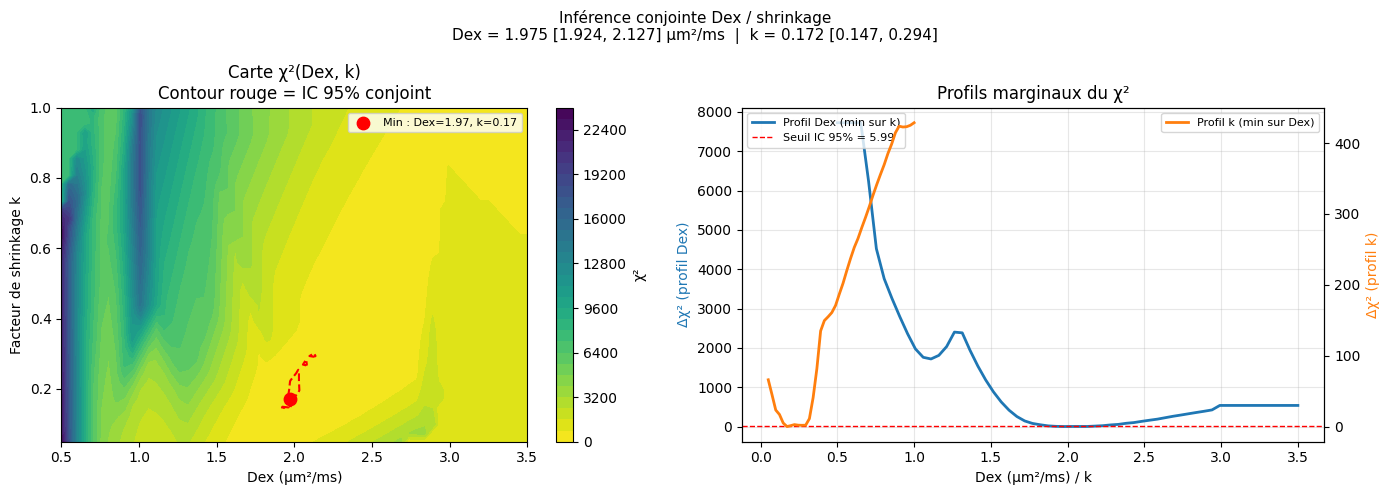

χ²_min / (N - 2) = 24.199  (N=6 points, 2 paramètres libres)


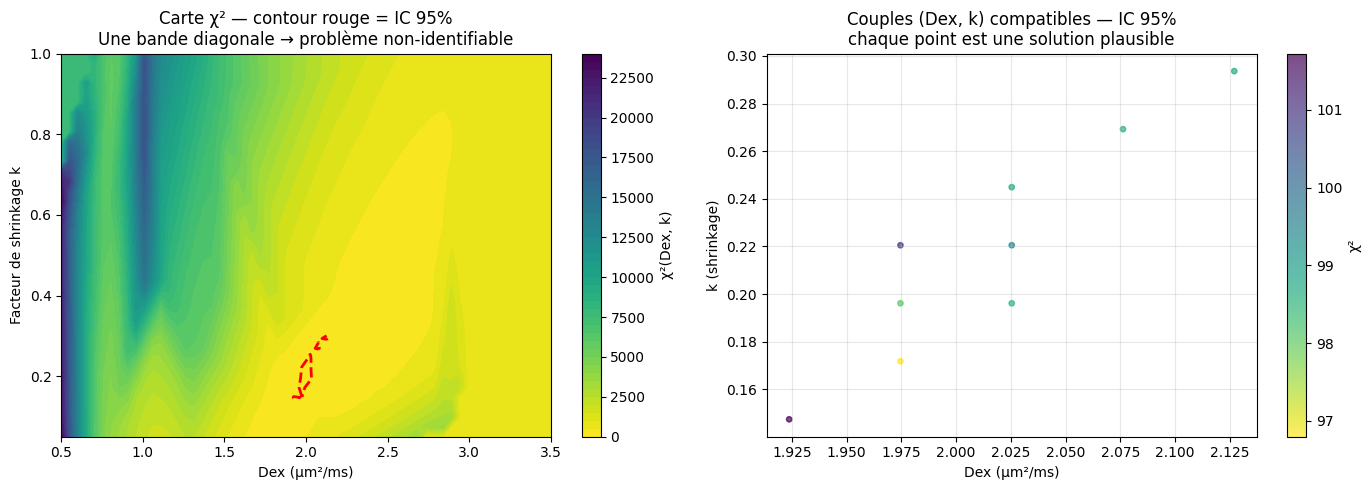

Corrélation Dex–k dans l'IC 95% : r = 0.918
→ Couplage fort — problème non-identifiable
f dans la LUT  : [0.000, 1.000]
f QuPath brut  : 0.700
f corrigé k=0.5 : 0.350
f corrigé k=0.2 : 0.140
f corrigé k=0.1 : 0.070
f QuPath brut : 0.7000
Unité attendue : fraction volumique sans dimension [0, 1]
N_v estimé : 0.000417 cellules/µm³
N_v en cellules/mm³ : 416981

Référence littérature gliome : ~50 000 - 200 000 cellules/mm³
Soit f ~ 0.05 - 0.20 pour r3D ~ 5 µm
r2D_mean      : 5.805 µm
r3D_mean      : 7.373 µm
roi_area_um2  : 522100.2 µm²
n_cells       : 3390
slice_width   : 4 µm

N_v           : 0.000416 cellules/µm³
V_cell        : 1678.73 µm³
f calculé     : 0.6982
f stocké JSON : 0.7000

r2D = 5.805 µm  — attendu ~4-8 µm pour une cellule tumorale
r3D = 7.373 µm  — attendu ~5-10 µm
V_cell = 1678.89 µm³
N_v = 416000 cellules/mm³

f = 0.698
Empilement maximal physique : ~0.64 (aléatoire) à 0.74 (FCC)


In [37]:
# ── Visualisation of the Dex / k degeneracy ──────────────────────────────
# Run after the inference cell (result must be defined)

from scipy.stats import chi2 as chi2_dist
delta = chi2_dist.ppf(0.95, df=2)   # ≈ 5.99
# ── ROI parameters from the already loaded JSONs ────────────────────────
pat_id   = 3
he       = 1
exp      = 4
roi_name = "ROI1"
TD       = 19

# Histological data
r3D_mean = results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["mean_r3D"]
r_std    = results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["std_r3D"]
f_mean   = density_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["density_3d"]

# Raw QuPath data
cell_file  = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
df_cells   = pd.read_csv(os.path.join(full_path_dir, cell_file), sep='\t', engine='python')
df_annot   = pd.read_csv(os.path.join(full_path_dir, annot_file), sep='\t', engine='python')

df_roi       = df_cells[df_cells["Parent"] == roi_name]
roi_area_um2 = df_annot.loc[df_annot["Name"] == roi_name, "Area µm^2"].values[0]

cell_areas   = df_roi["Cell: Area"].to_numpy()
max_calipers = df_roi["Cell: Max caliper"].to_numpy()
min_calipers = df_roi["Cell: Min caliper"].to_numpy()

# DWI data from combined.ipynb
subset     = df_p3[(df_p3["TD"] == f"{TD}ms") & (df_p1["b_value"] <= 7.5 * 1000)]
subset     = subset.sort_values("b_value")
df_dwi_roi = subset.copy()

# ── Call ─────────────────────────────────────────────────────────────────────
result_shrinkage = infer_Dex_shrinkage_chi2(
    df_dwi        = df_dwi_roi,
    cell_areas    = cell_areas,
    max_calipers  = max_calipers,
    min_calipers  = min_calipers,
    roi_area_um2  = roi_area_um2,
    TD            = TD,
    tri           = tri,
    signals_lut   = signals_lut,
    params_lut    = params_lut,
    slice_width_um = 4,
    bval_max_um2  = 7.5,
    Dex_grid      = np.linspace(0.5, 3.5, 60),
    k_grid        = np.linspace(0.05, 1.0, 40)
)

plot_degeneracy_valley(
    chi2_map  = result_shrinkage["chi2_map"],
    Dex_grid  = result_shrinkage["Dex_grid"],
    k_grid    = result_shrinkage["k_grid"],
    chi2_min  = result_shrinkage["chi2_min"],
    delta     = delta,
)

print(f"f in the LUT   : [{params_lut[:,0].min():.3f}, {params_lut[:,0].max():.3f}]")
print(f"f QuPath raw   : {f_mean:.3f}")
print(f"f corrected k=0.5 : {f_mean * 0.5:.3f}")
print(f"f corrected k=0.2 : {f_mean * 0.2:.3f}")
print(f"f corrected k=0.1 : {f_mean * 0.1:.3f}")

# Checking density_3d units
print(f"f QuPath raw: {f_mean:.4f}")
print(f"Expected unit: dimensionless volume fraction [0, 1]")
print(f"Estimated N_v: {f_mean / (4/3 * np.pi * r3D_mean**3):.6f} cells/µm³")
print(f"N_v in cells/mm³: {f_mean / (4/3 * np.pi * r3D_mean**3) * 1e9:.0f}")

# Literature reference values
print(f"\nLiterature reference for glioma: ~50,000 - 200,000 cells/mm³")
print(f"i.e. f ~ 0.05 - 0.20 for r3D ~ 5 µm")

# Step-by-step recomputation for this ROI
print(f"r2D_mean      : {results_json[f'Patient_{pat_id}'][f'H&E_{he}'][f'exp_{exp}'][roi_name]['mean_r2D']:.3f} µm")
print(f"r3D_mean      : {r3D_mean:.3f} µm")
print(f"roi_area_um2  : {roi_area_um2:.1f} µm²")
print(f"n_cells       : {len(df_roi)}")
print(f"slice_width   : 4 µm")

r2D  = results_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]["mean_r2D"]
n    = len(df_roi)
area = roi_area_um2

N_v    = n / ((4 + 2 * r2D) * area)
V_cell = (4/3) * np.pi * r3D_mean**3
f_calc = N_v * V_cell

print(f"\nN_v           : {N_v:.6f} cellules/µm³")
print(f"V_cell        : {V_cell:.2f} µm³")
print(f"f computed    : {f_calc:.4f}")
print(f"f stored JSON : {f_mean:.4f}")

# Is the r2D value plausible?
print(f"\nr2D = {r2D:.3f} µm  — expected ~4-8 µm for a tumour cell")
print(f"r3D = {r3D_mean:.3f} µm  — expected ~5-10 µm")

# V_cell = (4/3) * pi * r3D³
# r3D = 7.373 µm
import numpy as np
r3D = 7.373
V_cell = (4/3) * np.pi * r3D**3
print(f"V_cell = {V_cell:.2f} µm³")

# For comparison — spherical cell of radius 7.373 µm
# = diameter of 14.7 µm, consistent with a tumour cell
# BUT the issue is that N_v * V_cell = 0.000416 * 1678 = 0.70

# Check N_v in cells/mm³
print(f"N_v = {0.000416 * 1e9:.0f} cellules/mm³")  # 416 000

# Maximum random packing density = ~64%
# Maximum face-centred cubic packing = ~74%
print(f"\nf = {V_cell * 0.000416:.3f}")
print(f"Maximum physical packing: ~0.64 (random) to 0.74 (FCC)")

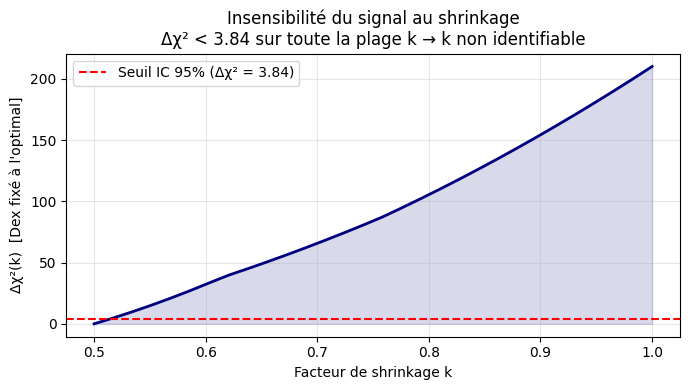

In [ ]:
# ── Signal insensitivity to shrinkage k ───────────
# Chi² profile as a function of k alone (Dex fixed at its optimum)

chi2_map = np.array(result["chi2_map"])
Dex_grid = np.array(result["Dex_grid"])
k_grid   = np.array(result["k_grid"])
j_best   = np.argmin(np.abs(Dex_grid - result["Dex_best"]))  # indice de Dex_best

chi2_k_profile = chi2_map[:, j_best]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_grid, chi2_k_profile - chi2_k_profile.min(), color='navy', lw=2)
ax.axhline(3.84, color='red', ls='--', lw=1.5, label='95% CI threshold (Δχ² = 3.84)')
ax.fill_between(k_grid, 0, chi2_k_profile - chi2_k_profile.min(),
                alpha=0.15, color='navy')
ax.set_xlabel('Shrinkage factor k')
ax.set_ylabel("Δχ²(k)  [Dex fixed at optimum]")
ax.set_title('Signal insensitivity to shrinkage\n'
             'Δχ² < 3.84 across the full k range → k non-identifiable')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Dex inference across all ROIs — consensus value

In [ ]:
def infer_Dex_all_rois(density_json, roi_results, df_dwi,
                       full_path_dir, exp, TD,
                       tri, signals_lut, params_lut,
                       Dex_grid=None):
    """
    Infer Dex for each available ROI and return a consensus value.
    """
    if Dex_grid is None:
        Dex_grid = np.linspace(0.5, 3.5, 100)

    # LUT b-value range for filtering
    bvals_lut_um2 = np.array(sequence_lut['bval'][0][0]).flatten()
    bval_lut_min, bval_lut_max = bvals_lut_um2.min(), bvals_lut_um2.max()

    # Extract and filter DWI signal for this TD
    td_label = f"{TD}ms"
    subset   = (df_dwi[df_dwi["TD"] == td_label]
                .copy()
                .assign(bval_um2=lambda d: d["b_value"] / 1000)
                .query("bval_um2 > 0 and bval_um2 <= @bval_lut_max")
                .sort_values("bval_um2"))

    out_of_range = subset["bval_um2"] < bval_lut_min
    if out_of_range.any():
        print(f"[infer_Dex_all_rois] Warning: {out_of_range.sum()} b-value(s) below LUT "
              f"range [{bval_lut_min:.3f}, {bval_lut_max:.3f}] ms/um2 — discarded.")
        subset = subset[~out_of_range]

    signal_dwi  = subset["signal"].to_numpy()
    sigma_noise = np.where(subset["noise"].to_numpy() < 1e-6, 1e-6, subset["noise"].to_numpy())
    bval_list   = subset["bval_um2"].to_numpy()

    if len(bval_list) == 0:
        raise ValueError("No usable DWI b-values after filtering — check TD and LUT range.")

    results = []   # store results per ROI

    for pat_id_str, pat_data in density_json.items():
        for he_key, he_data in pat_data.items():
            exp_key = f"exp_{exp}"
            if exp_key not in he_data:
                continue

            for roi_name, dens_data in he_data[exp_key].items():
                try:
                    f_mean   = dens_data["density_3d"]
                    r3D_mean = roi_results[pat_id_str][he_key][exp_key][roi_name]["mean_r3D"]
                    r_std    = roi_results[pat_id_str][he_key][exp_key][roi_name]["std_r3D"]
                except KeyError:
                    continue

                # Compute chi² for this ROI — interpolate LUT curve to DWI b-values
                chi2_values = []
                for Dex in Dex_grid:
                    bvals_curve, sig_curve = get_signal_curve_lut(
                        f_mean, Dex, r3D_mean, r_std, TD,
                        tri, signals_lut, params_lut)
                    log_sig_curve = np.log(np.clip(sig_curve, 1e-10, None))
                    log_S_pred    = np.interp(bval_list, bvals_curve, log_sig_curve)
                    sig_sim       = np.exp(log_S_pred)
                    if np.any(np.isnan(sig_sim)):
                        chi2_values.append(np.nan)
                        continue
                    chi2_val = np.sum(((signal_dwi - sig_sim) / sigma_noise)**2)
                    chi2_values.append(chi2_val)

                chi2_values = np.array(chi2_values)
                best_idx    = np.nanargmin(chi2_values)
                Dex_best    = Dex_grid[best_idx]
                chi2_min    = chi2_values[best_idx]

                # 95% CI
                from scipy.stats import chi2 as chi2_dist
                threshold   = chi2_min + chi2_dist.ppf(0.95, df=1)
                ci_mask     = chi2_values < threshold
                Dex_ci_low  = Dex_grid[ci_mask].min() if ci_mask.any() else np.nan
                Dex_ci_high = Dex_grid[ci_mask].max() if ci_mask.any() else np.nan

                results.append({
                    "roi":         f"{pat_id_str}|{he_key}|{roi_name}",
                    "f":           f_mean,
                    "r3D":         r3D_mean,
                    "Dex_best":    Dex_best,
                    "Dex_ci_low":  Dex_ci_low,
                    "Dex_ci_high": Dex_ci_high,
                    "chi2_min":    chi2_min,
                    "chi2_reduit": chi2_min / (len(bval_list) - 1)
                })

                print(f"{pat_id_str}|{he_key}|{roi_name} : "
                      f"f={f_mean:.3f} | Dex={Dex_best:.3f} "
                      f"[{Dex_ci_low:.3f}, {Dex_ci_high:.3f}] | "
                      f"chi2_red={chi2_min/(len(bval_list)-1):.2f}")

    df_results = pd.DataFrame(results)

    # ── Consensus value ───────────────────────────────────────────────────
    # Weighted average by 1/chi2_min: better-fitting ROIs have more weight
    weights            = 1.0 / df_results["chi2_min"]
    Dex_consensus      = np.average(df_results["Dex_best"], weights=weights)

    # Global CI: weighted average of individual CIs
    Dex_ci_global_low  = np.average(df_results["Dex_ci_low"],  weights=weights)
    Dex_ci_global_high = np.average(df_results["Dex_ci_high"], weights=weights)

    print(f"\n── Dex consensus value ──────────────────────────────────")
    print(f"Dex_consensus = {Dex_consensus:.3f} um2/ms "
          f"[{Dex_ci_global_low:.3f}, {Dex_ci_global_high:.3f}]")
    print(f"(weighted average by 1/chi2_min over {len(df_results)} ROIs)")

    # ── Visualization ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(df_results["roi"], df_results["Dex_best"],
            xerr=[df_results["Dex_best"] - df_results["Dex_ci_low"],
                  df_results["Dex_ci_high"] - df_results["Dex_best"]],
            capsize=4, color='steelblue', alpha=0.7)
    ax.axvline(Dex_consensus, color='red', lw=2, ls='--',
               label=f'Consensus = {Dex_consensus:.3f} um2/ms')
    ax.axvspan(Dex_ci_global_low, Dex_ci_global_high,
               alpha=0.1, color='red', label='95% CI consensus')
    ax.set_xlabel('Dex (um2/ms)')
    ax.set_title('Dex inferred per ROI — weighted average by fit quality')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    return Dex_consensus, Dex_ci_global_low, Dex_ci_global_high, df_results

# Mapping patient 
df_dwi_map = {
    "Patient_1": df_p1,
    "Patient_3": df_p3
}

# Bvalues check
for pat_id_str, df_dwi in df_dwi_map.items():
    print(f"\n{pat_id_str} :")
    for td in df_dwi["TD"].unique():
        bvals = df_dwi[df_dwi["TD"] == td]["b_value"].sort_values().tolist()
        print(f"  TD={td} : {bvals}")

# Inference per patient
all_results = []

for pat_id_str, df_dwi in df_dwi_map.items():
    print(f"\n{'='*50}")
    print(f"Dex inference — {pat_id_str}")
    print(f"{'='*50}")

    Dex_consensus, Dex_ci_low, Dex_ci_high, df_res = infer_Dex_all_rois(
        density_json = {pat_id_str: density_json[pat_id_str]},
        roi_results  = {pat_id_str: results_json[pat_id_str]},
        df_dwi       = df_dwi,
        full_path_dir = full_path_dir,
        exp          = 4,
        TD           = 19,
        tri          = tri,
        signals_lut  = signals_lut,
        params_lut   = params_lut,
        Dex_grid     = np.linspace(0.5, 3.5, 100)
    )

    all_results.append({
        "patient":       pat_id_str,
        "Dex_consensus": Dex_consensus,
        "Dex_ci_low":    Dex_ci_low,
        "Dex_ci_high":   Dex_ci_high,
        "df_rois":       df_res
    })

# Summary
print(f"\n{'='*50}")
print("RÉSUMÉ — Dex consensus par patient")
print(f"{'='*50}")
for r in all_results:
    print(f"{r['patient']} : Dex = {r['Dex_consensus']:.3f} "
          f"[{r['Dex_ci_low']:.3f}, {r['Dex_ci_high']:.3f}] µm²/ms")

# # Select the parameters for the bootstrap

In [ ]:
def analyze_bootstrap_convergence(cell_areas, max_calipers, min_calipers,
                                   roi_area_um2, slice_width_um,
                                   Dex_central, bval, TD,
                                   tri, signals_lut, params_lut,
                                   n_max=1000,
                                   tolerance=0.01):
    """
    Computes bootstrap statistics for increasing values of n,
    and identifies the minimal n at which convergence is reached.

    tolerance : maximum relative variation accepted on the CI width
                between two consecutive steps (e.g. 0.01 = 1%)
    """
    # Steps to test — log-spaced to cover small n values
    n_values = np.unique(np.logspace(
        np.log10(20), np.log10(n_max), num=30
    ).astype(int))

    # Generate ALL samples at once, then subsample
    # → avoids re-running the random generator at each step
    n_cells = len(cell_areas)
    all_indices = [
        np.random.choice(n_cells, size=n_cells, replace=True)
        for _ in range(n_max)
    ]

    # Pre-compute signals for each replicate
    all_signals = []
    for idx in all_indices:
        max_cal_b = max_calipers[idx]
        min_cal_b = min_calipers[idx]

        mean_max = np.mean(max_cal_b)
        mean_min = np.mean(min_cal_b)
        std_max  = np.std(max_cal_b, ddof=1)
        std_min  = np.std(min_cal_b, ddof=1)

        r2D     = np.sqrt(mean_max * mean_min / 4)
        std_r2D = 0.25 * np.sqrt(
            (mean_max / mean_min) * std_min**2 +
            (mean_min / mean_max) * std_max**2
        )
        r3D     = 1.27 * r2D
        std_r3D = 1.27 * std_r2D

        N_v    = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
        V_cell = (4/3) * np.pi * r3D**3
        f_boot = N_v * V_cell

        sig = interpolate_signal(f_boot, Dex_central, r3D, std_r3D,
                                 bval, TD, tri, signals_lut, params_lut)
        if not np.isnan(sig):
            all_signals.append(sig)

    all_signals = np.array(all_signals)

    # Compute statistics for each step n
    results = {"n": [], "mean": [], "std": [], "p2.5": [], "p97.5": [], "ic_width": []}

    for n in n_values:
        if n > len(all_signals):
            break
        subset = all_signals[:n]
        p_low  = np.percentile(subset, 2.5)
        p_high = np.percentile(subset, 97.5)
        results["n"].append(n)
        results["mean"].append(np.mean(subset))
        results["std"].append(np.std(subset))
        results["p2.5"].append(p_low)
        results["p97.5"].append(p_high)
        results["ic_width"].append(p_high - p_low)

    # ── Convergence criterion ────────────────────────────────────────────────
    # Relative variation of the CI width between consecutive steps
    ic_widths   = np.array(results["ic_width"])
    rel_changes = np.abs(np.diff(ic_widths) / ic_widths[:-1])

    n_converged = None
    for k, rel_change in enumerate(rel_changes):
        if rel_change < tolerance:
            n_converged = results["n"][k + 1]
            break

    # ── Visualisation ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Panel 1: percentile evolution
    ax = axes[0]
    ax.plot(results["n"], results["p2.5"],  color='steelblue',
            label='P2.5', lw=1.5)
    ax.plot(results["n"], results["p97.5"], color='coral',
            label='P97.5', lw=1.5)
    ax.fill_between(results["n"], results["p2.5"], results["p97.5"],
                    alpha=0.15, color='steelblue')
    if n_converged:
        ax.axvline(n_converged, color='red', ls='--', lw=1.2,
                   label=f'Convergence: n={n_converged}')
    ax.set_xlabel('Number of bootstrap replicates')
    ax.set_ylabel('Normalized signal')
    ax.set_title('Stability of percentiles 2.5 / 97.5')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Panel 2: CI width
    ax = axes[1]
    ax.plot(results["n"], ic_widths, color='navy', lw=1.5)
    if n_converged:
        ax.axvline(n_converged, color='red', ls='--', lw=1.2,
                   label=f'n={n_converged}')
        ax.axhline(ic_widths[-1], color='gray', ls=':', lw=1,
                   label='Asymptotic width')
    ax.set_xlabel('Number of bootstrap replicates')
    ax.set_ylabel('CI 95% width (P97.5 - P2.5)')
    ax.set_title("Convergence of the CI width")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Panel 3: relative variation between steps (criterion)
    ax = axes[2]
    ax.plot(results["n"][1:], rel_changes * 100,
            color='darkorange', lw=1.5)
    ax.axhline(tolerance * 100, color='red', ls='--', lw=1.2,
               label=f'Tolerance threshold = {tolerance*100:.1f}%')
    if n_converged:
        ax.axvline(n_converged, color='red', ls='--', lw=1.2,
                   label=f'n={n_converged}')
    ax.set_xlabel('Number of bootstrap replicates')
    ax.set_ylabel('Relative variation of the CI width (%)')
    ax.set_title('Convergence criterion')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Bootstrap convergence analysis — b={bval} ms/µm², TD={TD} ms',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    if n_converged:
        print(f"Convergence reached at n = {n_converged} "
              f"(tolerance {tolerance*100:.1f}% on the CI width)")
    else:
        print(f"Convergence not reached before n={n_max} — "
              f"increase n_max or tolerance")

    return n_converged, results

# Run once to adjust bootstrap parameters : worst case = patient 1, H&E 2, expansion 4, ROI2
pat_id  = 1       
he      = 2
exp     = 4
roi_name = "ROI2"

cell_file = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"

df_cells = pd.read_csv(os.path.join(full_path_dir, cell_file), sep='\t', engine='python')
df_annot = pd.read_csv(os.path.join(full_path_dir, annot_file), sep='\t', engine='python')

df_roi       = df_cells[df_cells["Parent"] == roi_name]
roi_area_um2 = df_annot.loc[df_annot["Name"] == roi_name, "Area µm^2"].values[0]

n_opt, conv_results = analyze_bootstrap_convergence(
    cell_areas   = df_roi["Cell: Area"].to_numpy(),
    max_calipers = df_roi["Cell: Max caliper"].to_numpy(),
    min_calipers = df_roi["Cell: Min caliper"].to_numpy(),
    roi_area_um2 = roi_area_um2,
    slice_width_um = 4,
    Dex_central  = 2.2,
    bval         = 1.5,   # intermediate b-value, sensitive to parameters
    TD           = 19,
    tri = Delaunay(params_lut), signals_lut=signals_lut, params_lut=params_lut,
    n_max        = 1000,
    tolerance    = 0.01   # 1% relative variation = stability criterion
)

# Boostrapping on cells variability

In [ ]:
def bootstrap_signal_from_cells(cell_areas, max_calipers, min_calipers, roi_area_um2, slice_width_um, Dex_central, bval, TD, tri, signals_lut, params_lut, n_bootstrap=300):
    """Bootstrap on cell variability: at each replicate, cells are resampled with replacement"""
    n_cells = len(cell_areas)
    signals_boot = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(n_cells, size=n_cells, replace=True)
        areas_b   = cell_areas[idx]
        max_cal_b = max_calipers[idx]
        min_cal_b = min_calipers[idx]

        mean_max = np.mean(max_cal_b)
        mean_min = np.mean(min_cal_b)
        std_max  = np.std(max_cal_b, ddof=1)
        std_min  = np.std(min_cal_b, ddof=1)

        r2D = np.sqrt(mean_max * mean_min / 4)

        # Uncertainty propagation for r2D
        std_r2D = 0.25 * np.sqrt(
            (mean_max / mean_min) * std_min**2 +
            (mean_min / mean_max) * std_max**2
        )

        r3D     = 1.27 * r2D
        std_r3D = 1.27 * std_r2D 

        # Abercrombie's 3D density estimation
        N_v    = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
        V_cell = (4/3) * np.pi * r3D**3
        f_boot = N_v * V_cell

        sig = interpolate_signal(f_boot, Dex_central, r3D, std_r3D,
                                 bval, TD, tri, signals_lut, params_lut)
        if not np.isnan(sig):
            signals_boot.append(sig)

    signals_boot = np.array(signals_boot)
    return {
        "mean":   np.mean(signals_boot),
        "median": np.median(signals_boot),
        "std":    np.std(signals_boot),
        "p2.5":   np.percentile(signals_boot, 2.5),
        "p97.5":  np.percentile(signals_boot, 97.5),
    }



# Bootstrapping on density intra ROI

In [ ]:
def bootstrap_signal_from_density(df_roi, roi_area_um2, slice_width_um, Dex_central, bval, TD, tri, signals_lut, params_lut, n_bootstrap=200):
    """
    Bootstrap on cell density within the ROI.
    
    Each replicate resamples the cells with replacement → the effective
    number of cells varies → N_v and f vary → signal varies.
    
    Cell size (r3D, std_r3D) is recalculated at each replicate
    but will vary little (as expected with a fixed experiment).
    """
    cell_areas   = df_roi["Cell: Area"].to_numpy()
    max_calipers = df_roi["Cell: Max caliper"].to_numpy()
    min_calipers = df_roi["Cell: Min caliper"].to_numpy()
    n_cells      = len(cell_areas)

    signals_boot = []
    f_boot_list  = []   # to inspect the f distribution

    for _ in range(n_bootstrap):
        # Resampling with replacement → some cells counted
        # multiple times, others absent → variable effective density
        idx      = np.random.choice(n_cells, size=n_cells, replace=True)
        n_eff    = len(np.unique(idx))   # number of unique cells drawn

        areas_b   = cell_areas[idx]
        max_cal_b = max_calipers[idx]
        min_cal_b = min_calipers[idx]

        mean_max  = np.mean(max_cal_b)
        mean_min  = np.mean(min_cal_b)
        std_max   = np.std(max_cal_b, ddof=1)
        std_min   = np.std(min_cal_b, ddof=1)

        r2D     = np.sqrt(mean_max * mean_min / 4)
        std_r2D = 0.25 * np.sqrt(
            (mean_max / mean_min) * std_min**2 +
            (mean_min / mean_max) * std_max**2
        )
        r3D     = 1.27 * r2D
        std_r3D = 1.27 * std_r2D

        # 3D density — this is where bootstrap variability comes into play
        # n_cells in the numerator varies with each draw
        N_v    = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
        V_cell = (4/3) * np.pi * r3D**3
        f_boot = N_v * V_cell

        f_boot_list.append(f_boot)

        sig = interpolate_signal(f_boot, Dex_central, r3D, std_r3D,
                                 bval, TD, tri, signals_lut, params_lut)
        if not np.isnan(sig):
            signals_boot.append(sig)

    signals_boot = np.array(signals_boot)
    f_boot_arr   = np.array(f_boot_list)

    return {
        "mean":    np.mean(signals_boot),
        "median":  np.median(signals_boot),
        "std":     np.std(signals_boot),
        "p2.5":    np.percentile(signals_boot, 2.5),
        "p97.5":   np.percentile(signals_boot, 97.5),
        # f distribution for diagnostics
        "f_mean":  np.mean(f_boot_arr),
        "f_std":   np.std(f_boot_arr),
        "f_p2.5":  np.percentile(f_boot_arr, 2.5),
        "f_p97.5": np.percentile(f_boot_arr, 97.5),
    }

# Bootstrapping on density inter ROI

In [39]:
def bootstrap_signal_interROI(df_all_rois, roi_names, roi_areas,
                               slice_width_um, Dex_central,
                               bval, TD, tri, signals_lut, params_lut,
                               n_bootstrap=200):
    """
    Inter-ROI bootstrap: at each replicate, one ROI is drawn at random
    with replacement to estimate the variability due to the choice of
    histological sampling area.

    df_all_rois : dict {roi_name: DataFrame} of cells per ROI
    roi_areas   : dict {roi_name: area in µm²}
    """
    signals_boot = []
    roi_list     = list(roi_names)

    for _ in range(n_bootstrap):
        # Sample one ROI at random with replacement
        roi_sampled  = np.random.choice(roi_list)
        df_roi       = df_all_rois[roi_sampled]
        roi_area_um2 = roi_areas[roi_sampled]

        res = bootstrap_signal_from_density(
            df_roi, roi_area_um2, slice_width_um,
            Dex_central, bval, TD,
            tri, signals_lut, params_lut,
            n_bootstrap=50   # reduced intra bootstrap to limit computation time
        )
        signals_boot.append(res["mean"])

    signals_boot = np.array(signals_boot)
    return {
        "mean":   np.mean(signals_boot),
        "median": np.median(signals_boot),
        "p2.5":   np.percentile(signals_boot, 2.5),
        "p97.5":  np.percentile(signals_boot, 97.5),
        "std":    np.std(signals_boot),
    }

# Diagnosis of bootstrapping results

In [ ]:
pat_id  = 1       
he      = 2
exp     = 4
roi_name = "ROI2"

cell_file = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"

df_cells = pd.read_csv(os.path.join(full_path_dir, cell_file), sep='\t', engine='python')
df_annot = pd.read_csv(os.path.join(full_path_dir, annot_file), sep='\t', engine='python')

df_roi       = df_cells[df_cells["Parent"] == roi_name]
roi_area_um2 = df_annot.loc[df_annot["Name"] == roi_name, "Area µm^2"].values[0]

tri = Delaunay(params_lut)

if pat_id == 1 :
    dex_central=2.7
else:
    dex_central=2.2

# Verification: f and signal distribution on a single ROI
res = bootstrap_signal_from_density(
    df_roi, roi_area_um2, slice_width_um=4,
    Dex_central=dex_central, bval=1.5, TD=19,
    tri=tri, signals_lut=signals_lut, params_lut=params_lut,
    n_bootstrap=200
)


print(f"f_boot  : {res['f_mean']:.4f} ± {res['f_std']:.4f}  "
      f"IC95% [{res['f_p2.5']:.4f}, {res['f_p97.5']:.4f}]")
print(f"Signal  : {res['mean']:.4f} ± {res['std']:.4f}  "
      f"IC95% [{res['p2.5']:.4f}, {res['p97.5']:.4f}]")
print(f"Signal CI width: {res['p97.5'] - res['p2.5']:.5f}")

allowed_ROI = {"ROI1", "ROI2", "ROI3", "ROI4"}

df_all_rois = {}
roi_areas   = {}

for pat_id in Patient:
    for he in H_E:

        df_all_rois = {}
        roi_areas   = {}

        cell_file  = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
        annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
        cell_path  = os.path.join(full_path_dir, cell_file)
        annot_path = os.path.join(full_path_dir, annot_file)

        if not os.path.exists(cell_path) or not os.path.exists(annot_path):
            print(f"Patient {pat_id} H&E {he}: missing files, skipping")
            print(f"  → Expected {cell_file} and {annot_file} in {full_path_dir}\n")
            continue

        df_cells = pd.read_csv(cell_path,  sep='\t', engine='python')
        df_annot = pd.read_csv(annot_path, sep='\t', engine='python')

        for roi in {"ROI1", "ROI2", "ROI3", "ROI4"}:
            df_r = df_cells[df_cells["Parent"] == roi]
            if len(df_r) == 0:
                print(f"Patient {pat_id} H&E {he}: {roi} - no cell found, skipped")
                continue
            area = df_annot.loc[df_annot["Name"] == roi, "Area µm^2"].values
            if len(area) == 0:
                continue
            try:
                f_val = density_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi]["density_3d"]
            except KeyError:
                continue

            df_all_rois[roi] = df_r
            roi_areas[roi]   = area[0]
            print(f"  {roi}: {len(df_r)} cells | f = {f_val:.4f}")

        n_rois = len(df_all_rois)
        print(f"\nPatient {pat_id} H&E {he}: {n_rois} ROI(s) available")

        if n_rois < 2:
            print("  → inter-ROI bootstrap skipped (only one ROI)\n")
            continue

        if pat_id == 1 :
            dex_central=2.7
        else:
            dex_central=2.2

        res_inter = bootstrap_signal_interROI(
            df_all_rois, list(df_all_rois.keys()), roi_areas,
            slice_width_um=4, Dex_central=dex_central,
            bval=1.5, TD=19,
            tri=tri, signals_lut=signals_lut, params_lut=params_lut,
            n_bootstrap=200
        )

        print(f"  Inter-ROI — CI95% [{res_inter['p2.5']:.4f}, {res_inter['p97.5']:.4f}] "
              f"| width = {res_inter['p97.5'] - res_inter['p2.5']:.5f}\n")

Patient 1 H&E 1 : ROI2 - aucune cellule trouvée, ignoré
Patient 1 H&E 1 : ROI3 - aucune cellule trouvée, ignoré
  ROI1 : 3390 cellules | f = 0.5600
Patient 1 H&E 1 : ROI4 - aucune cellule trouvée, ignoré

Patient 1 H&E 1 : 1 ROI(s) disponible(s)
  → bootstrap inter-ROI ignoré (une seule ROI)

  ROI2 : 9926 cellules | f = 0.2800
  ROI3 : 2935 cellules | f = 0.2000
  ROI1 : 3179 cellules | f = 0.3700
Patient 1 H&E 2 : ROI4 - aucune cellule trouvée, ignoré

Patient 1 H&E 2 : 3 ROI(s) disponible(s)
  Inter-ROI — IC95% [0.1144, 0.1591] | largeur = 0.04467

  ROI2 : 1032 cellules | f = 0.6000
  ROI3 : 1176 cellules | f = 0.5100
  ROI1 : 990 cellules | f = 0.5900
  ROI4 : 955 cellules | f = 0.4200

Patient 3 H&E 1 : 4 ROI(s) disponible(s)
  Inter-ROI — IC95% [0.1917, 0.1955] | largeur = 0.00386

Patient 3 H&E 2 : fichiers manquants, passage au suivant
  → Chercher Patient_3_H&E_2_exp_3.txt et Patient_3_H&E_2_annot.txt dans c:\Users\maely\OneDrive\Bureau\ENSTA\CESURE\AMBER\Validation\Qupath_pr

# Spatial bootstrap — random windows over the full histological slide

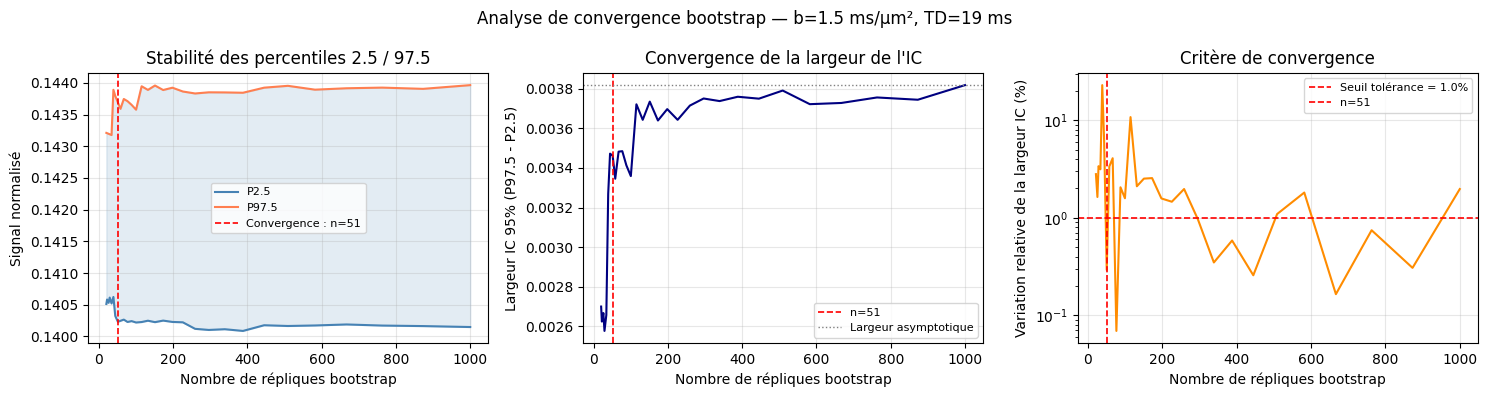

✓ Convergence atteinte à n = 51 (tolérance 1.0% sur la largeur de l'IC)


In [41]:
def bootstrap_spatial_roi(df_cells_full, df_annot_full,
                           roi_size_um, slice_width_um,
                           Dex_best, bval, TD,
                           tri, signals_lut, params_lut,
                           n_bootstrap=200,
                           allowed_rois=None):
    """
    Spatial bootstrap: draws random sub-regions (moving windows) over the
    tissue, constrained to the bounding boxes of the annotated ROIs.

    This avoids the selection bias introduced by sampling from the full
    slide bounding box, which includes background/non-tissue areas and
    causes only the densest windows to be accepted.

    Parameters
    ----------
    df_cells_full : QuPath DataFrame of ALL cells (must include 'Parent'
                    column to identify which ROI each cell belongs to,
                    and 'Centroid X µm' / 'Centroid Y µm' coordinates).
    df_annot_full : QuPath annotation DataFrame (used for ROI area info;
                    the actual bounding boxes are derived from cell centroids).
    roi_size_um   : side length of the square sampling window in µm.
                    Should be comparable to the smallest annotated ROI.
    allowed_rois  : list of ROI names to use as valid tissue regions
                    (defaults to all ROIs found in df_cells_full["Parent"]).

    Notes on the f > 0.8 bug in the previous version
    -------------------------------------------------
    The old version sampled windows from the full bounding box of all cells
    on the slide. Windows outside the tissue were sparse (< 10 cells) and
    discarded, so only the densest windows survived — a strong selection
    bias. Here, windows are placed only within existing annotated ROI
    bounding boxes, which represent validated tissue regions, and the
    empty-window threshold is removed (sparse windows are biologically
    informative too).
    """
    if "Centroid X µm" not in df_cells_full.columns:
        raise ValueError("Column 'Centroid X µm' missing — check QuPath export.")
    if "Parent" not in df_cells_full.columns:
        raise ValueError("Column 'Parent' missing — re-export with ROI parent info.")

    x_all = df_cells_full["Centroid X µm"].to_numpy()
    y_all = df_cells_full["Centroid Y µm"].to_numpy()

    # ── Build per-ROI bounding boxes from cell centroids ─────────────────
    # We use cell coordinates rather than the annotation file because
    # df_annot_full typically lacks polygon vertices.
    if allowed_rois is None:
        roi_names_all = df_cells_full["Parent"].unique()
    else:
        roi_names_all = allowed_rois

    roi_boxes = []
    for roi_name in roi_names_all:
        mask_roi = df_cells_full["Parent"] == roi_name
        if mask_roi.sum() < 5:
            continue
        x_r = df_cells_full.loc[mask_roi, "Centroid X µm"].to_numpy()
        y_r = df_cells_full.loc[mask_roi, "Centroid Y µm"].to_numpy()
        xmin, xmax = x_r.min(), x_r.max()
        ymin, ymax = y_r.min(), y_r.max()
        # Keep only ROIs large enough to fit at least one window
        if (xmax - xmin) < roi_size_um or (ymax - ymin) < roi_size_um:
            print(f"  [bootstrap_spatial_roi] ROI '{roi_name}' smaller than "
                  f"window ({roi_size_um} µm) — skipped.")
            continue
        roi_boxes.append({
            "name":  roi_name,
            "x_min": xmin, "x_max": xmax,
            "y_min": ymin, "y_max": ymax,
            "placeable_area": (xmax - xmin - roi_size_um) * (ymax - ymin - roi_size_um),
        })

    if not roi_boxes:
        raise ValueError(
            f"No annotated ROI is large enough for a {roi_size_um:.0f} µm window. "
            "Reduce roi_size_um or annotate larger ROIs."
        )

    # Weight ROIs proportionally to their 'placeable area' so that larger
    # ROIs contribute more replicates (unbiased spatial coverage).
    placeable_areas = np.array([r["placeable_area"] for r in roi_boxes])
    weights = placeable_areas / placeable_areas.sum()

    roi_area_um2 = roi_size_um ** 2
    signals_boot = []
    f_boot_list  = []
    attempts     = 0
    max_attempts = n_bootstrap * 30  # safety cap

    while len(f_boot_list) < n_bootstrap and attempts < max_attempts:
        attempts += 1

        # 1. Pick a ROI proportional to its placeable area
        chosen = roi_boxes[np.random.choice(len(roi_boxes), p=weights)]

        # 2. Place window fully inside that ROI's bounding box
        x0 = np.random.uniform(chosen["x_min"], chosen["x_max"] - roi_size_um)
        y0 = np.random.uniform(chosen["y_min"], chosen["y_max"] - roi_size_um)

        # 3. Count cells within the window (across all ROIs, not just the
        #    chosen one, so boundary cells are not artificially excluded)
        mask = (
            (x_all >= x0) & (x_all <= x0 + roi_size_um) &
            (y_all >= y0) & (y_all <= y0 + roi_size_um)
        )
        df_window = df_cells_full[mask]
        n_cells = len(df_window)

        # Accept even empty windows — they represent low-density tissue regions.
        # A minimum of 2 cells is kept only to avoid degenerate std estimates.
        if n_cells < 2:
            f_boot_list.append(0.0)
            signals_boot.append(1.0)   # S/S0 → 1 at f ≈ 0
            continue

        # 4. Estimate biological parameters from the window cells
        max_cal = df_window["Cell: Max caliper"].to_numpy()
        min_cal = df_window["Cell: Min caliper"].to_numpy()

        mean_max = np.mean(max_cal)
        mean_min = np.mean(min_cal)
        std_max  = np.std(max_cal,  ddof=1) if n_cells > 1 else 0.0
        std_min  = np.std(min_cal,  ddof=1) if n_cells > 1 else 0.0

        r2D = np.sqrt(mean_max * mean_min / 4)
        std_r2D = 0.25 * np.sqrt(
            (mean_max / mean_min) * std_min**2 +
            (mean_min / mean_max) * std_max**2
        ) if n_cells > 1 else 0.0
        r3D     = 1.27 * r2D
        std_r3D = 1.27 * std_r2D

        # 5. Abercrombie 3D density and volume fraction
        N_v    = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
        V_cell = (4/3) * np.pi * r3D**3
        f_boot = N_v * V_cell
        f_boot_list.append(f_boot)

        if f_boot > 1.0:
            print(f"  [WARNING f>1] ROI={chosen['name']} | "
                  f"window=({x0:.1f},{y0:.1f})+{roi_size_um:.1f}µm | "
                  f"n_cells={n_cells} | r2D={r2D:.2f}µm | "
                  f"roi_area={roi_area_um2:.0f}µm² | "
                  f"N_v={N_v:.5f} | f={f_boot:.3f}")

        sig = interpolate_signal(
            f_boot, Dex_best, r3D, std_r3D,
            bval, TD, tri, signals_lut, params_lut
        )
        signals_boot.append(sig if not np.isnan(sig) else np.nan)

    signals_boot = np.array(signals_boot)
    f_boot_arr   = np.array(f_boot_list)

    # Drop NaN signals for statistics (keep f distribution intact)
    valid_mask   = ~np.isnan(signals_boot)
    signals_valid = signals_boot[valid_mask]

    print(f"Valid replicates: {len(signals_valid)} / {n_bootstrap} "
          f"(attempts: {attempts})")
    print(f"ROIs used: {[r['name'] for r in roi_boxes]}")
    print(f"f_boot: {np.mean(f_boot_arr):.4f} ± {np.std(f_boot_arr):.4f} "
          f"[{np.percentile(f_boot_arr, 2.5):.4f}, "
          f"{np.percentile(f_boot_arr, 97.5):.4f}]")

    if len(signals_valid) == 0:
        raise RuntimeError("No valid signal replicates — check LUT coverage.")

    return {
        "mean":   float(np.mean(signals_valid)),
        "p2.5":   float(np.percentile(signals_valid, 2.5)),
        "p97.5":  float(np.percentile(signals_valid, 97.5)),
        "std":    float(np.std(signals_valid)),
        "f_mean": float(np.mean(f_boot_arr)),
        "f_std":  float(np.std(f_boot_arr)),
        "f_p2.5": float(np.percentile(f_boot_arr, 2.5)),
        "f_p97.5":float(np.percentile(f_boot_arr, 97.5)),
        "n_valid": int(len(signals_valid)),
    }


def bootstrap_signal_poisson(f_central, r3D, std_r3D, n_cells_obs,
                              roi_area_um2, slice_width_um, r2D,
                              Dex_central, bval, TD,
                              tri, signals_lut, params_lut,
                              n_bootstrap=300):
    """
    Poisson bootstrap for cell density uncertainty.

    Models the cell count in a fixed volume as a Poisson process:
      n ~ Poisson(lambda),  lambda = N_v * V_sample
    The MLE is lambda = n_cells_obs, so we draw counts from Poisson(n_cells_obs).

    This is the standard parametric approach when the ROIs are too small or
    too few to support spatial resampling. It gives a theoretically motivated
    SE(N_v) = N_v / sqrt(n_cells_obs), i.e. ~10% for n=100 cells.

    The cell geometry (r3D, std_r3D) is kept fixed at the point estimate
    because it is dominated by the systematic expansion-factor bias rather
    than sampling noise.

    Parameters
    ----------
    f_central    : central estimate of f from Abercrombie + QuPath
    r3D, std_r3D : 3D radius and std at the point estimate (fixed across replicates)
    n_cells_obs  : observed cell count in the ROI
    roi_area_um2 : ROI area in µm²
    slice_width_um : histological section thickness (µm)
    r2D          : 2D radius (used only in the Abercrombie denominator)
    """
    V_sample = (slice_width_um + 2 * r2D) * roi_area_um2
    V_cell   = (4/3) * np.pi * r3D**3

    signals_boot = []
    f_boot_list  = []

    for _ in range(n_bootstrap):
        n_boot = np.random.poisson(n_cells_obs)
        if n_boot == 0:
            f_boot_list.append(0.0)
            signals_boot.append(1.0)
            continue
        N_v_boot = n_boot / V_sample
        f_boot   = N_v_boot * V_cell
        f_boot_list.append(f_boot)

        sig = interpolate_signal(f_boot, Dex_central, r3D, std_r3D,
                                 bval, TD, tri, signals_lut, params_lut)
        signals_boot.append(sig if not np.isnan(sig) else np.nan)

    signals_boot = np.array(signals_boot)
    f_boot_arr   = np.array(f_boot_list)
    valid         = ~np.isnan(signals_boot)
    signals_valid = signals_boot[valid]

    se_f_theoretical = f_central / np.sqrt(n_cells_obs)
    print(f"Poisson bootstrap — n_cells={n_cells_obs}, "
          f"SE(f) theoretical={se_f_theoretical:.4f}, "
          f"SE(f) empirical={np.std(f_boot_arr):.4f}")

    return {
        "mean":   float(np.mean(signals_valid)),
        "p2.5":   float(np.percentile(signals_valid, 2.5)),
        "p97.5":  float(np.percentile(signals_valid, 97.5)),
        "std":    float(np.std(signals_valid)),
        "f_mean": float(np.mean(f_boot_arr)),
        "f_std":  float(np.std(f_boot_arr)),
        "f_p2.5": float(np.percentile(f_boot_arr, 2.5)),
        "f_p97.5":float(np.percentile(f_boot_arr, 97.5)),
        "n_valid": int(len(signals_valid)),
    }

# Run spatial bootstrap and save results in JSON

In [17]:
SPATIAL_BOOTSTRAP_FILE = "signal_results_spatial_bootstrap.json"

if not os.path.exists(SPATIAL_BOOTSTRAP_FILE):

    Dex_options  = [2.8, 2.2]  # patient 1 has higher Dex than patient 3
    bval_options = [  # update if LUT b-value range changes
        [0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],
        [0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 17.8]
    ]
    TD_options     = [19, 49]
    slice_width_um = 4
    tri            = Delaunay(params_lut)

    spatial_json = {}

    for pat_id in Patient:
        spatial_json[f"Patient_{pat_id}"] = {}

        for he in H_E:
            spatial_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}

            for exp in expansion:
                spatial_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"] = {}

                # Load full-slide cell file (all ROIs combined)
                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    continue
                df_annot       = pd.read_csv(annot_path, sep='\t', engine='python')
                df_annot_sorted = df_annot.sort_values(by="Name")
                areas          = df_annot_sorted["Area µm^2"].to_numpy()
                roi_size_um    = np.sqrt(np.min(areas))/2   # window = average ROI size
                print(f"  Patient {pat_id} | H&E {he} | exp {exp} | "
                      f"roi_size_um={roi_size_um:.1f}µm "
                      f"(from min area={np.min(areas):.0f}µm²) | "
                      f"annotations={list(df_annot_sorted['Name'].unique())}")

                cell_file = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
                cell_path = os.path.join(full_path_dir, cell_file)
                if not os.path.exists(cell_path):
                    continue
                df_cells_full = pd.read_csv(cell_path, sep='\t', engine='python')

                # "full_slide" plays the same role as a ROI key in the original format
                spatial_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"]["full_slide"] = {}

                for j, TD in enumerate(TD_options):
                    spatial_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"]["full_slide"][f"TD_{TD}"] = {}

                    means, p_lows, p_highs, stds = [], [], [], []

                    # Only use validated ROI annotations as sampling zones
                    valid_roi_names = list(df_annot_sorted["Name"].unique())

                    for bval in bval_options[j]:
                        res = bootstrap_spatial_roi(
                            df_cells_full  = df_cells_full,
                            df_annot_full  = df_annot_sorted,
                            roi_size_um    = roi_size_um,
                            slice_width_um = slice_width_um,
                            Dex_best       = Dex_options[Patient.index(pat_id)],
                            bval           = bval,
                            TD             = TD,
                            tri            = tri,
                            signals_lut    = signals_lut,
                            params_lut     = params_lut,
                            n_bootstrap    = 300,
                            allowed_rois   = valid_roi_names,
                        )
                        means.append(res["mean"])
                        stds.append(res["std"])
                        p_lows.append(res["p2.5"])
                        p_highs.append(res["p97.5"])

                    Dex_best_val = Dex_options[Patient.index(pat_id)]
                    spatial_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"]["full_slide"][f"TD_{TD}"][f"Dex_{Dex_best_val}"] = {
                        "bval":         bval_options[j],
                        "signals_mean": means,
                        "signals_std":  stds,
                        "p_low":        p_lows,
                        "p_high":       p_highs
                    }

                print(f"  Patient {pat_id} | H&E {he} | exp {exp} | TD={TD}")

    with open(SPATIAL_BOOTSTRAP_FILE, "w") as f:
        json.dump(spatial_json, f, indent=4)
    print(f"\nJSON saved: {SPATIAL_BOOTSTRAP_FILE}")

else:
    with open(SPATIAL_BOOTSTRAP_FILE, "r", encoding="utf-8") as f:
        spatial_json = json.load(f)
    print(f"Spatial bootstrap loaded from {SPATIAL_BOOTSTRAP_FILE}")

Bootstrap loaded from signal_results_bootstrap.json


# Run bootstrapping for cells variability and save results in JSON

In [ ]:
BOOTSTRAP_FILE = "signal_results_bootstrap.json"

if not os.path.exists(BOOTSTRAP_FILE):

    Din = 1
    Dex_options = [1.5, 2.2, 2.5]
    bval_options = [ #NEEDS TO BE UPDATED FOR THE NEW LUT
        [0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],
        [0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 17.8]
    ]
    TD_options = [19, 49]
    slice_width_um = 4
    tri = Delaunay(params_lut)

    bootstrap_json = {}

    for pat_id in Patient:
        bootstrap_json[f"Patient_{pat_id}"] = {}

        for he in H_E:
            bootstrap_json[f"Patient_{pat_id}"][f"H&E_{he}"] = {}

            for exp in expansion:
                bootstrap_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"] = {}

                # Loading Qupath data
                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    continue

                df_annot  = pd.read_csv(annot_path, sep='\t', engine='python')
                df_annot_sorted = df_annot.sort_values(by="Name")
                names  = df_annot_sorted["Name"].to_numpy()
                areas  = df_annot_sorted["Area µm^2"].to_numpy()

                cell_file = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
                cell_path = os.path.join(full_path_dir, cell_file)
                if not os.path.exists(cell_path):
                    continue

                df_cells = pd.read_csv(cell_path, sep='\t', engine='python')

                for i, roi_name in enumerate(names):
                    if roi_name not in {"ROI1", "ROI2", "ROI3", "ROI4"}:
                        continue

                    df_roi = df_cells[df_cells["Parent"] == roi_name]
                    if len(df_roi) == 0:
                        continue

                    # Raw data for bootstrap
                    cell_areas   = df_roi["Cell: Area"].to_numpy()
                    max_calipers = df_roi["Cell: Max caliper"].to_numpy()
                    min_calipers = df_roi["Cell: Min caliper"].to_numpy()
                    roi_area_um2 = areas[i]

                    bootstrap_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name] = {}

                    for j, TD in enumerate(TD_options):
                        bootstrap_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][f"TD_{TD}"] = {}

                        for Dex in Dex_options:
                            means, p_lows, p_highs, stds, medians = [], [], [], [], []

                            for bval in bval_options[j]:
                                res = bootstrap_signal_from_cells(
                                    cell_areas, max_calipers, min_calipers,
                                    roi_area_um2, slice_width_um,
                                    Dex_central=Dex,
                                    bval=bval, TD=TD,
                                    tri=tri,
                                    signals_lut=signals_lut,
                                    params_lut=params_lut,
                                    n_bootstrap=300
                                )
                                means.append(res["mean"])
                                medians.append(res["median"])
                                stds.append(res["std"])
                                p_lows.append(res["p2.5"])
                                p_highs.append(res["p97.5"])

                            bootstrap_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][f"TD_{TD}"][f"Dex_{Dex}"] = {
                                "bval":          bval_options[j],
                                "signals_mean":  means,
                                "signals_median": medians,
                                "signals_std":   stds,
                                "p_low":         p_lows,   # percentile 2.5%
                                "p_high":        p_highs   # percentile 97.5%
                            }

                        print(f"  ✓ Patient {pat_id} | H&E {he} | exp {exp} | {roi_name} | TD={TD}")

    with open(BOOTSTRAP_FILE, "w") as f:
        json.dump(bootstrap_json, f, indent=4)
    print(f"\nJSON saved : {BOOTSTRAP_FILE}")

else:
    with open(BOOTSTRAP_FILE, "r", encoding="utf-8") as f:
        bootstrap_json = json.load(f)
    print(f"Bootstrap loaded from {BOOTSTRAP_FILE}")

# Compute full inference with bootstrapping

In [ ]:
def compute_full_uncertainty(df_roi, roi_area_um2, slice_width_um,
                              Dex_ci_low, Dex_ci_high,
                              bval_um2, TD, tri, signals_lut, params_lut,
                              k_ci=(1.0, 1.0),
                              n_bootstrap=200):
    """
    Combined bootstrap: histological variability (QuPath) + uncertainty on Dex + shrinkage.

    At each iteration:
      - bootstrap draw on cells → (f_raw, r3D)
      - uniform draw of Dex in [Dex_ci_low, Dex_ci_high]
      - uniform draw of k in k_ci → f_corrected = f_raw * k
      - signal log-linearly interpolated to bval_um2

    Parameters
    ----------
    k_ci : tuple (k_low, k_high), default (1.0, 1.0) = no shrinkage correction
    """
    cell_areas   = df_roi["Cell: Area"].to_numpy()
    max_calipers = df_roi["Cell: Max caliper"].to_numpy()
    min_calipers = df_roi["Cell: Min caliper"].to_numpy()
    n_cells      = len(cell_areas)

    signals_boot = []

    for _ in range(n_bootstrap):
        # ── Source 1: QuPath variability ──────────────────────────────────
        idx       = np.random.choice(n_cells, size=n_cells, replace=True)
        max_cal_b = max_calipers[idx]
        min_cal_b = min_calipers[idx]

        mean_max = np.mean(max_cal_b)
        mean_min = np.mean(min_cal_b)
        std_max  = np.std(max_cal_b, ddof=1)
        std_min  = np.std(min_cal_b, ddof=1)

        r2D     = np.sqrt(mean_max * mean_min / 4)
        std_r2D = 0.25 * np.sqrt(
            (mean_max / mean_min) * std_min**2 +
            (mean_min / mean_max) * std_max**2
        )
        r3D     = 1.27 * r2D
        std_r3D = 1.27 * std_r2D

        N_v    = n_cells / ((slice_width_um + 2 * r2D) * roi_area_um2)
        f_raw  = N_v * (4/3) * np.pi * r3D**3

        # ── Source 2: uncertainty on k (shrinkage) ───────────────────────
        k_sample = np.random.uniform(k_ci[0], k_ci[1])
        f_boot   = f_raw * k_sample

        # ── Source 3: uncertainty on Dex ────────────────────────────────
        Dex_sample = np.random.uniform(Dex_ci_low, Dex_ci_high)

        # ── Signal with log-linear b-value interpolation ─────────────
        bvals_curve, sig_curve = get_signal_curve_lut(
            f_boot, Dex_sample, r3D, std_r3D, TD, tri, signals_lut, params_lut)
        log_sig = np.log(np.clip(sig_curve, 1e-10, None))
        sig     = float(np.exp(np.interp(bval_um2, bvals_curve, log_sig)))

        if not np.isnan(sig):
            signals_boot.append(sig)

    signals_boot = np.array(signals_boot)
    return {
        "mean":  float(np.mean(signals_boot)),
        "p2.5":  float(np.percentile(signals_boot, 2.5)),
        "p97.5": float(np.percentile(signals_boot, 97.5)),
        "std":   float(np.std(signals_boot)),
    }


def compute_full_uncertainty_curve(df_roi, roi_area_um2, slice_width_um,
                                   Dex_ci_low, Dex_ci_high,
                                   bvals_um2, TD, tri, signals_lut, params_lut,
                                   k_ci=(1.0, 1.0),
                                   n_bootstrap=200):
    """Apply compute_full_uncertainty over a list of b-values."""
    means, p_lows, p_highs = [], [], []
    for bval in bvals_um2:
        res = compute_full_uncertainty(
            df_roi, roi_area_um2, slice_width_um,
            Dex_ci_low, Dex_ci_high,
            bval, TD, tri, signals_lut, params_lut,
            k_ci=k_ci,
            n_bootstrap=n_bootstrap,
        )
        means.append(res["mean"])
        p_lows.append(res["p2.5"])
        p_highs.append(res["p97.5"])
    return np.array(means), np.array(p_lows), np.array(p_highs)

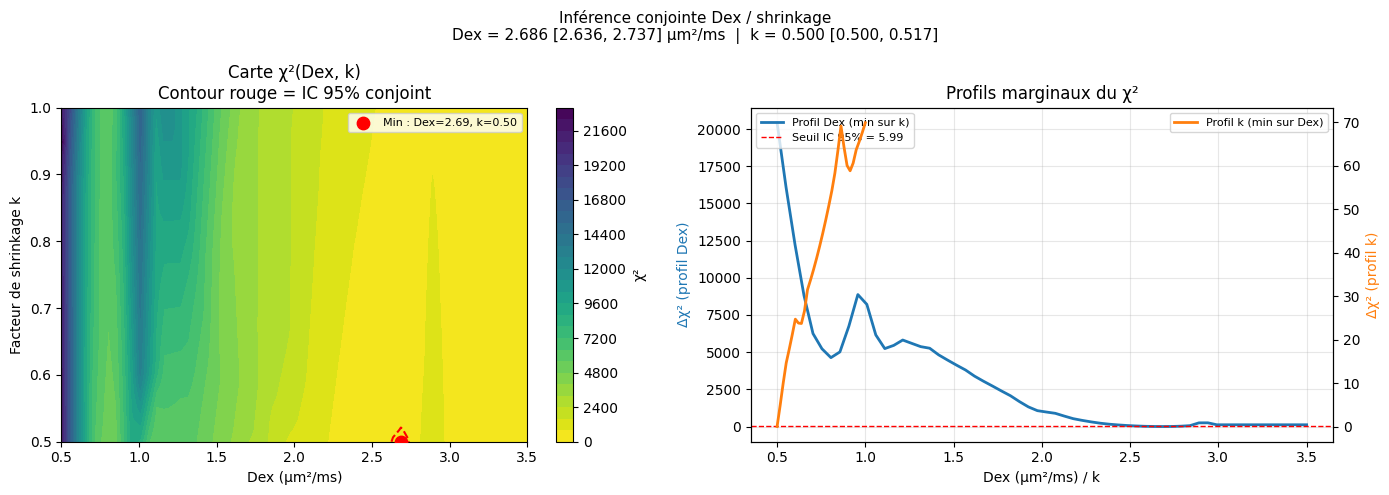

χ²_min / (N - 2) = 89.285  (N=6 points, 2 paramètres libres)

f brut     = 0.4823
f corrigé  = 0.2412  (k=0.500)
r3D        = 7.94 ± 0.90 µm


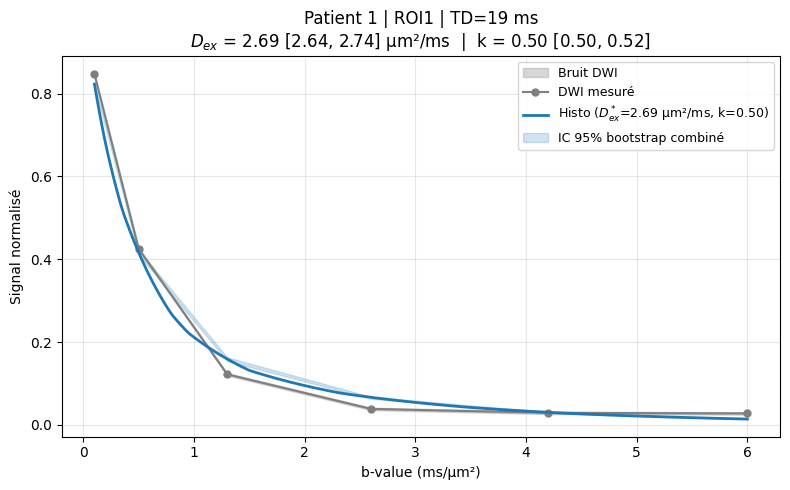

In [ ]:
# ── Step 1: joint Dex + shrinkage inference ───────────────────────────

tri = Delaunay(params_lut)

# Parameters to adjust
pat_id   = 1
he       = 2
exp      = 4
roi_name = "ROI1"
TD_val   = 19
df_dwi   = df_p1    # df_p1 → Patient 1 | df_p3 → Patient 3

cell_file  = f"Patient_{pat_id}_H&E_{he}_exp_{exp}.txt"
annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
df_cells   = pd.read_csv(os.path.join(full_path_dir, cell_file),  sep='\t', engine='python')
df_annot   = pd.read_csv(os.path.join(full_path_dir, annot_file), sep='\t', engine='python')

df_roi       = df_cells[df_cells["Parent"] == roi_name]
roi_area_um2 = df_annot.loc[df_annot["Name"] == roi_name, "Area µm^2"].values[0]

result = infer_Dex_shrinkage_chi2(
    df_dwi       = df_dwi,
    cell_areas   = df_roi["Cell: Area"].to_numpy(),
    max_calipers = df_roi["Cell: Max caliper"].to_numpy(),
    min_calipers = df_roi["Cell: Min caliper"].to_numpy(),
    roi_area_um2 = roi_area_um2,
    TD           = TD_val,
    tri          = tri,
    signals_lut  = signals_lut,
    params_lut   = params_lut,
)

print(f"\nf raw      = {result['f_raw']:.4f}")
print(f"f corrected = {result['f_corrected']:.4f}  (k={result['k_best']:.3f})")
print(f"r3D        = {result['r3D_mean']:.2f} ± {result['r3D_std']:.2f} µm")

# ── Steps 2+3: combined bootstrap + display ──────────────────────────────

td_str        = f"{TD_val}ms"
bvals_dwi_um2 = (
    df_dwi[df_dwi["TD"] == td_str]
    .assign(b=lambda d: d["b_value"] / 1000)
    .query("b > 0 and b <= 7.5")
    .sort_values("b")["b"]
    .to_numpy()
)

means, p_lows, p_highs = compute_full_uncertainty_curve(
    df_roi       = df_roi,
    roi_area_um2 = roi_area_um2,
    slice_width_um = 4,
    Dex_ci_low   = result["Dex_ci"][0],
    Dex_ci_high  = result["Dex_ci"][1],
    bvals_um2    = bvals_dwi_um2,
    TD           = TD_val,
    tri          = tri,
    signals_lut  = signals_lut,
    params_lut   = params_lut,
    k_ci         = result["k_ci"],
    n_bootstrap  = 300,
)

# Central curve: Dex_best + k_best + mean histo parameters
bvals_fine = np.linspace(bvals_dwi_um2.min(), bvals_dwi_um2.max(), 200)
bvals_lut_curve, sig_lut_central = get_signal_curve_lut(
    result["f_corrected"], result["Dex_best"],
    result["r3D_mean"], result["r3D_std"],
    TD_val, tri, signals_lut, params_lut,
)
sig_central = np.exp(np.interp(
    bvals_fine, bvals_lut_curve,
    np.log(np.clip(sig_lut_central, 1e-10, None))
))

# Measured DWI signal
df_dwi_td = (
    df_dwi[df_dwi["TD"] == td_str]
    .assign(b=lambda d: d["b_value"] / 1000)
    .query("b > 0 and b <= 7.5")
    .sort_values("b")
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(df_dwi_td["b"], df_dwi_td["signal"] - df_dwi_td["noise"],
                df_dwi_td["signal"] + df_dwi_td["noise"],
                color="tab:gray", alpha=0.3, label="DWI noise")
ax.plot(df_dwi_td["b"], df_dwi_td["signal"],
        "o-", color="tab:gray", lw=1.5, ms=5, label="Measured DWI")

ax.plot(bvals_fine, sig_central, "-", color="tab:blue", lw=2,
        label=(f"Histo ($D_{{ex}}^*$={result['Dex_best']:.2f} µm²/ms, "
               f"k={result['k_best']:.2f})"))

ax.fill_between(bvals_dwi_um2, p_lows, p_highs,
                color="tab:blue", alpha=0.2, label="Combined bootstrap 95% CI")

ax.set_xlabel(r"b-value (ms/µm²)")
ax.set_ylabel("Normalized signal")
ax.set_title(
    f"Patient {pat_id} | {roi_name} | TD={TD_val} ms\n"
    f"$D_{{ex}}$ = {result['Dex_best']:.2f} [{result['Dex_ci'][0]:.2f}, {result['Dex_ci'][1]:.2f}] µm²/ms  |  "
    f"k = {result['k_best']:.2f} [{result['k_ci'][0]:.2f}, {result['k_ci'][1]:.2f}]"
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Exponential decrease from histology and LUT

In [ ]:
# Load bootstrap results (p_low / p_high are bootstrap percentiles 2.5% and 97.5%)
with open("signal_results_bootstrap.json", "r", encoding="utf-8") as f:
    signal_json = json.load(f)
print("Signal results loaded from signal_results_bootstrap.json")

Signal results loaded from signal_results_bootstrap.json


# Exponential decay simulation with shrinkage

In [ ]:
if not os.path.exists("signal_results_shrinkage.json"):

    # Tissue parameters
    Din=1 #um2/s
    Dex_options=[1.5, 2.2, 2.5] #um2/s
    kappa=0.01 #um/s
    pulse_width=8 #ms
    bval_options=[[0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],[0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 18.8]] #ms/mm2 
    TD_options=[19, 49] #ms
    bvecs_options=[32, 64] #gradient directions
    tri=Delaunay(params_lut)

    # --- Shrinkage parameters ---
    shrinkage_factors = [0.5, 0.66, 0.7]

    signal_json_shrinkage = {}

    for pat_id in Patient:
        print(f"----------Graphs for patient {pat_id}----------")
        signal_json_shrinkage[f"Patient_{pat_id}"] = {}
        for he in H_E:
            signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"] = {}
            for exp in expansion:
                signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"] = {}

                annot_file = f"Patient_{pat_id}_H&E_{he}_annot.txt"
                annot_path = os.path.join(full_path_dir, annot_file)
                if not os.path.exists(annot_path):
                    print(f"No file named {annot_file} in {full_path_dir}")
                    continue

                df_annot = pd.read_csv(annot_path, sep='\t', engine='python')

                # Data ROIs
                df_annot_sorted = df_annot.sort_values(by="Name")
                names = df_annot_sorted["Name"].to_numpy()

                # Parameters from previous calculations
                preliminary_file = "roi_results.json"
                with open(preliminary_file, 'r', encoding='utf-8') as f:
                    preliminary_results=json.load(f)

                # Density
                density_file = "density_results.json"
                with open(density_file, 'r', encoding='utf-8') as f:
                    density_results=json.load(f)

                for i in range(len(names)):
                    roi_name = names[i]
                    signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name] = {}
                    
                    roi_data = preliminary_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
                    dens_data = density_results[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
                    
                    # Raw parameters before shrinkage correction
                    r_3d_mean_raw = roi_data["mean_r3D"]
                    r_3d_std_raw = roi_data["std_r3D"]
                    f_mean_raw = dens_data["density_3d"]
                    f_sigma_raw = dens_data["sigma_density_3d"]

                    # --- SHRINKAGE ---
                    for k in shrinkage_factors:
                        print(f"Calculating for shrinkage factor {k}...")
                        sh_key = f"shrinkage_{k}"
                        signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][sh_key] = {}

                        for j in {0, 1}:
                            TD = TD_options[j]
                            signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][sh_key][f"TD_{TD}"] = {}
                            
                            for Dex in Dex_options:
                                signals_mean, signals_std = [], []
                                signals_median, p_low_values, p_high_values = [], [], []
                                
                                for bval in bval_options[j]:
                                    
                                    print(f"Calculating for Patient {pat_id}, H&E {he}, exp {exp}, ROI {roi_name}, shrinkage {k}, TD {TD}, Dex {Dex}, bval {bval} with the parameters: f_mean_raw={f_mean_raw}, f_sigma_raw={f_sigma_raw}, r_3d_mean_raw={r_3d_mean_raw}, r_3d_std_raw={r_3d_std_raw}")
                                    mean_sig, std_sig, m_sig, p_low_sig, p_high_sig = get_signal_with_uncertainty_shrinkage(
                                        f_mean_raw, f_sigma_raw, r_3d_mean_raw, r_3d_std_raw, 
                                        Dex, bval, TD, tri, signals_lut, params_lut,
                                        shrinkage_factor=k, n_samples=1000
                                    )
                                    
                                    signals_mean.append(mean_sig)
                                    signals_std.append(std_sig)
                                    signals_median.append(m_sig)
                                    p_low_values.append(p_low_sig)
                                    p_high_values.append(p_high_sig)
                                
                                signal_json_shrinkage[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name][sh_key][f"TD_{TD}"][f"Dex_{Dex}"] = {
                                    "bval": bval_options[j],
                                    "signals_mean": signals_mean,
                                    "signals_std": signals_std,
                                    "signals_median": signals_median,
                                    "p_low": p_low_values,
                                    "p_high": p_high_values,
                                    "applied_params": {"f": f_mean_raw*k} 
                                }

    # Saving results JSON
    output_name = "signal_results_shrinkage.json"
    with open(output_name, "w") as f:
        json.dump(signal_json_shrinkage, f, indent=4)
    print(f"File saved : {output_name}")

else:
    # If the simulation file already exists
    with open("signal_results_shrinkage.json", 'r', encoding='utf-8') as f:
        signal_json_shrinkage = json.load(f)

    print("Shrinkage signal results loaded from signal_results_shrinkage.json")

Shrinkage signal results loaded from signal_results_shrinkage.json


# Extreme geometry

In [ ]:
if not os.path.exists("signal_results_geom.json"):
    
    # Tissue parameters
    Din=1 #um2/s
    Dex_options=[1.5, 2.2, 2.5] #um2/s
    kappa=0.01 #um/s
    pulse_width=8 #ms
    bval_options=[[0.05, 0.35, 0.8, 1.5, 2.4, 3.45, 4.75, 6],[0.2, 0.95, 2.3, 4.25, 6.75, 9.85, 13.5, 18.8]] #ms/mm2 
    TD_options=[19, 49] #ms
    bvecs_options=[32, 64] #gradient directions
    tri=Delaunay(params_lut)

    signal_json_geom={}

    # Parameters for extreme geometries
    r_3d_mean = [3, 9]
    r_3d_std = 0.5
    f_mean = [0.1, 0.8]
    f_sigma = 0.02
                                
    for r in r_3d_mean:
        signal_json_geom[f"r_{r}"] = {}
        for f in f_mean:
            signal_json_geom[f"r_{r}"][f"f_{f}"] = {}
            for j in range(len(TD_options)):
                TD = TD_options[j]
                signal_json_geom[f"r_{r}"][f"f_{f}"][f"TD_{TD}"]={}
                
                for Dex in Dex_options:
                    signals_mean = []
                    signals_std = []
                    signals_median = []
                    p_low_values = []
                    p_high_values = []
                    
                    for bval in bval_options[j]:
                        
                        mean_sig, std_sig, m_sig, p_low_sig, p_high_sig = get_signal_with_uncertainty(
                            f, f_sigma, r, r_3d_std, Dex, bval, TD, tri, signals_lut, params_lut, n_samples=1000
                        )
                        signals_mean.append(mean_sig)
                        signals_std.append(std_sig)
                        signals_median.append(m_sig)
                        p_low_values.append(p_low_sig)
                        p_high_values.append(p_high_sig)
                    
                    signal_json_geom[f"r_{r}"][f"f_{f}"][f"TD_{TD}"][f"Dex_{Dex}"] = {
                        "bval": bval_options[j],
                        "signals_mean": signals_mean,
                        "signals_std": signals_std,
                        "signals_median": signals_median,
                        "p_low": p_low_values,
                        "p_high": p_high_values
                    }

        # Saving results JSON
        with open("signal_results_geom.json", "w") as f:
            json.dump(signal_json_geom, f, indent=4)
        print("JSON generated : signal_results_geom.json")

else:
    # If the simulation file already exists
    
    with open("signal_results_geom.json", 'r', encoding='utf-8') as f:
        signal_json_geom = json.load(f)

    print("Signal results loaded from signal_results_geom.json")

Signal results loaded from signal_results_geom.json


# Comparison shrinkage factors

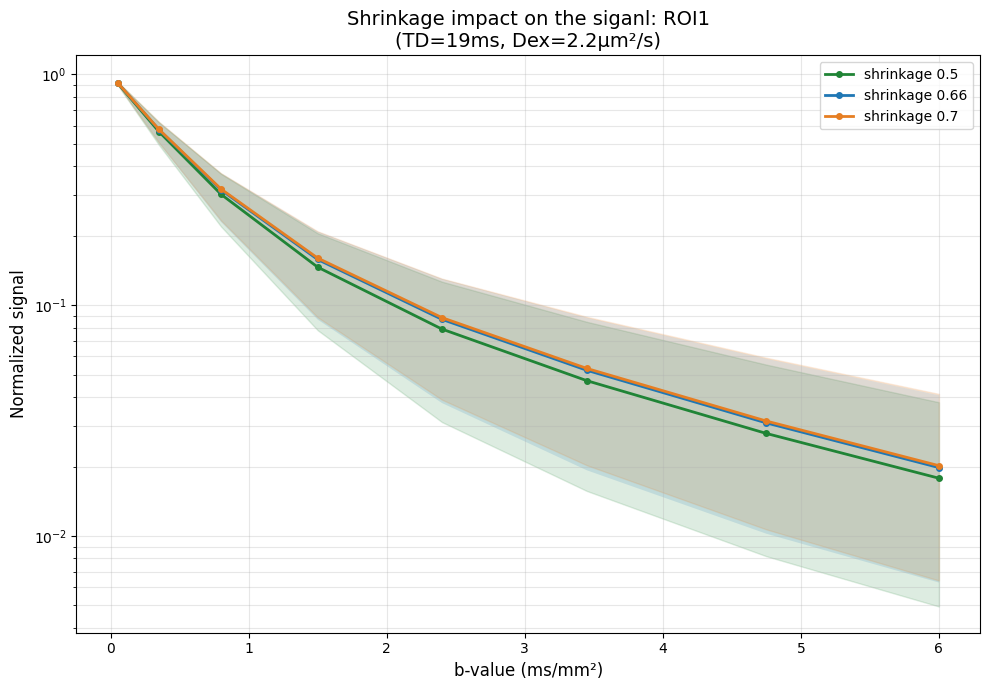

In [ ]:
def plot_shrinkage_comparison(signal_json, pat_id, he, exp, roi_name, td_val, dex_val):
    """
    Function to display the impact of shrinkage on the simulated signal for a given ROI, TD and Dex.
    Mean signal and uncertainty (percentiles) are plotted for each shrinkage factor.
    """
    plt.figure(figsize=(10, 7))
    
    colors = {
        "original": "black",
        "shrinkage_0.9": "#1d70a7",
        "shrinkage_0.7": "#e67e22", 
        "shrinkage_0.5": "#208436" 
    }

    # Get the right roi data
    roi_dict = signal_json[f"Patient_{pat_id}"][f"H&E_{he}"][f"exp_{exp}"][roi_name]
    
    for key in roi_dict.keys():
        if "shrinkage" not in key: continue
        
        data = roi_dict[key][f"TD_{td_val}"][f"Dex_{dex_val}"]
        
        bvals = data["bval"]
        mean_sig = np.array(data["signals_mean"])
        p_low = np.array(data["p_low"])
        p_high = np.array(data["p_high"])
        
        label = key.replace("_", " ")
        color = colors.get(key, None)

        # Plot the mean signal
        plt.plot(bvals, mean_sig, 'o-', markersize = 4, label=f"{label}", color=color, linewidth=2)
        
        # Plot the uncertainty envelope (percentiles)
        plt.fill_between(bvals, p_low, p_high, color=color, alpha=0.15)

    plt.yscale('log')
    plt.xlabel('b-value (ms/mm²)', fontsize=12)
    plt.ylabel('Normalized signal', fontsize=12)
    plt.title(f'Shrinkage impact on the siganl: {roi_name}\n(TD={td_val}ms, Dex={dex_val}µm²/s)', fontsize=14)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Put the parameters value
plot_shrinkage_comparison(signal_json_shrinkage, "1", "1", "4", "ROI1", 19, 2.2)

# Display exponential decrease : compare expansion coefficient

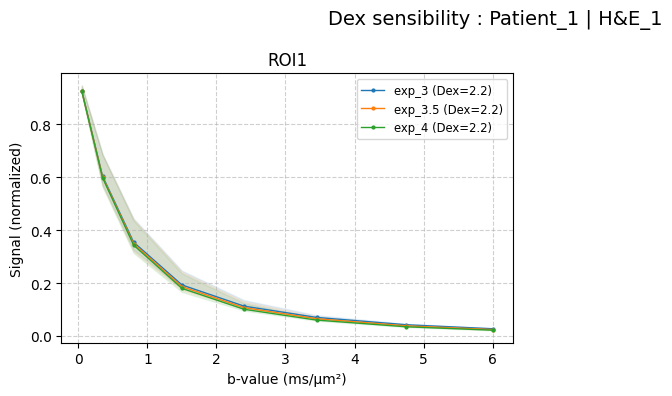

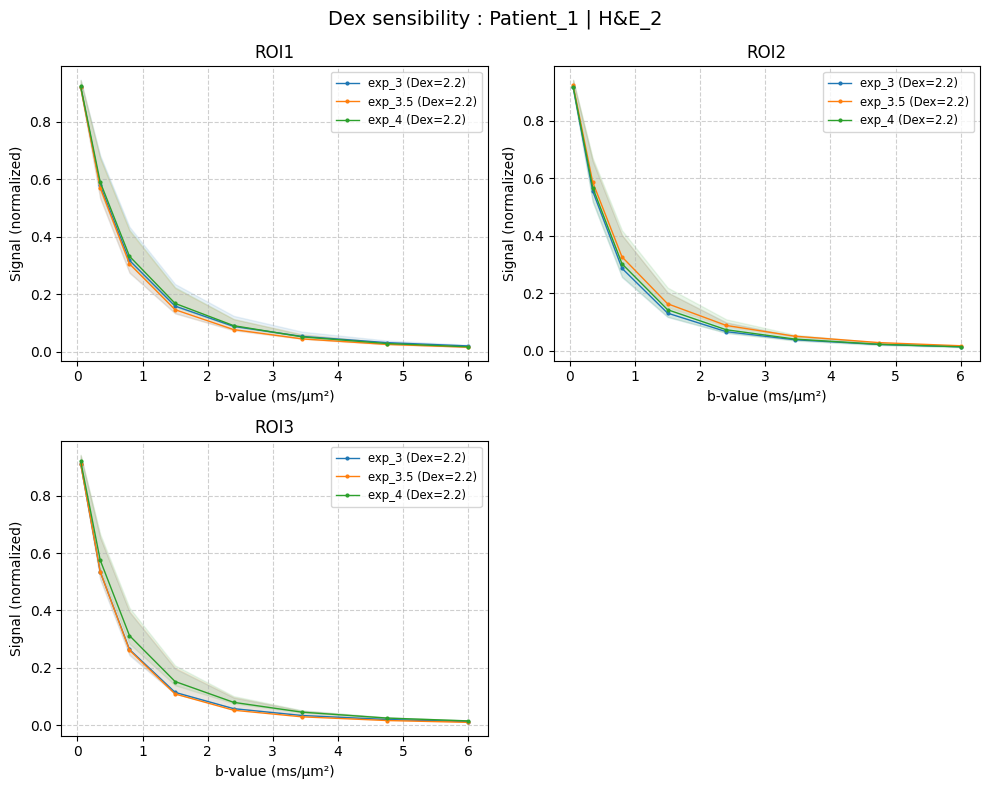

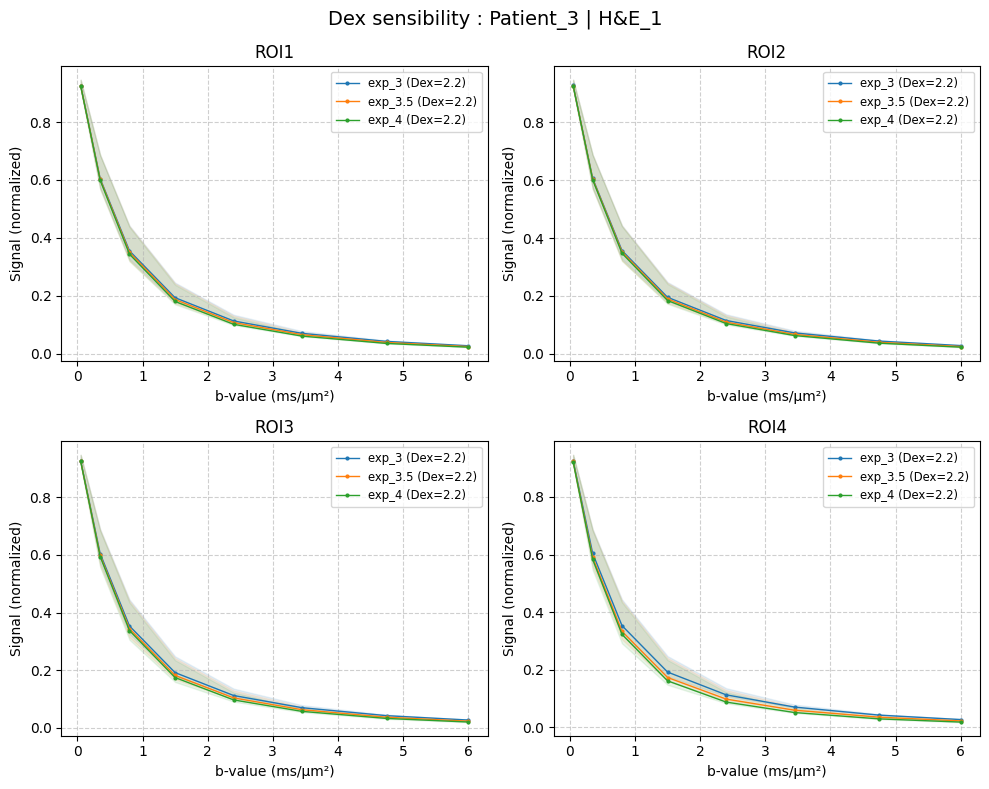

In [ ]:
Dex_min = 1.5
Dex_central = 2.2
Dex_max = 2.5
Dex_options = [Dex_min, Dex_central, Dex_max]

exp_colors = ['tab:blue', 'tab:orange', 'tab:green']

for pat_id in signal_json.keys():
    for he in signal_json[pat_id].keys():
        #print(json.dumps(signal_json[pat_id][he], indent=4, ensure_ascii=False))
        roi_list = list(
            signal_json[pat_id][he][list(signal_json[pat_id][he].keys())[0]].keys()
        )
        #print(roi_list)

        if len(roi_list) == 0:
            continue  

        ncols = 2
        nrows = math.ceil(len(roi_list) / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4*nrows))
        axes = axes.flatten()

        for r_idx, roi_name in enumerate(roi_list):

            ax = axes[r_idx]

            for idx, exp2 in enumerate(signal_json[pat_id][he].keys()):
                color = exp_colors[idx]
                TD_key = list(signal_json[pat_id][he][exp2][roi_name].keys())[0]

                signals = {}

                for Dex in Dex_options:
                    data = signal_json[pat_id][he][exp2][roi_name][TD_key][f"Dex_{Dex}"]
                    bvals = np.array(data['bval'])
                    signals[Dex] = np.array(data['signals_mean'])

                ax.plot(
                    bvals,
                    signals[Dex_central],
                    color=color,
                    linewidth=1,
                    marker='o',
                    markersize=2,
                    label=f"{exp2} (Dex={Dex_central})"
                )

                ax.fill_between(
                    bvals,
                    signals[Dex_min],
                    signals[Dex_max],
                    color=color,
                    alpha=0.1
                )

            ax.legend(loc='upper right', fontsize='small')
            ax.set_xlabel("b-value (ms/µm²)")
            ax.set_ylabel("Signal (normalized)")
            ax.set_title(f"{roi_name}")
            ax.grid(True, linestyle='--', alpha=0.6)

        for j in range(len(roi_list), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"Dex sensibility : {pat_id} | {he}", fontsize=14)
        fig.tight_layout()
        plt.show()

# Display exp decrease : compare ROIs

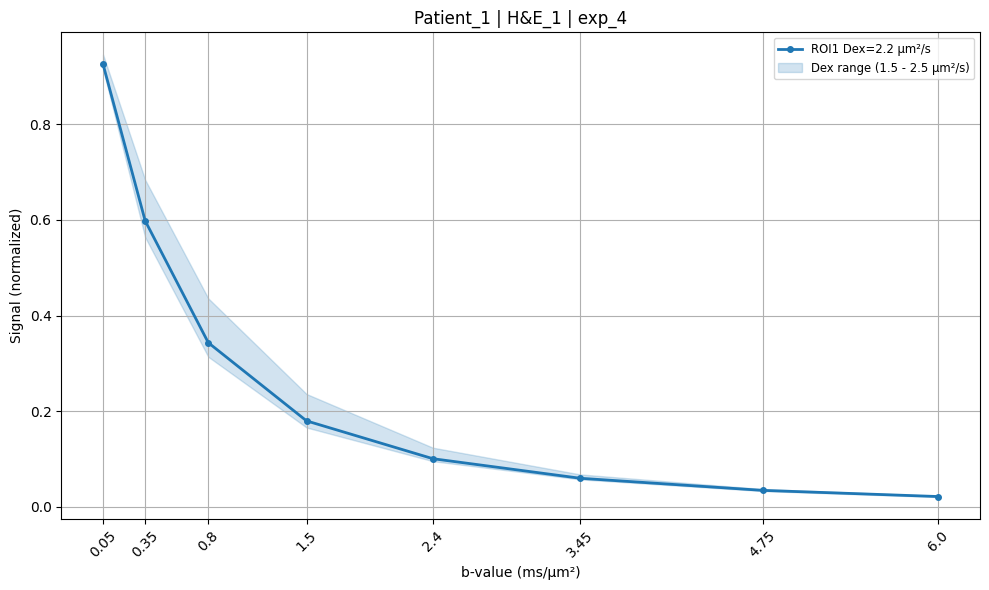

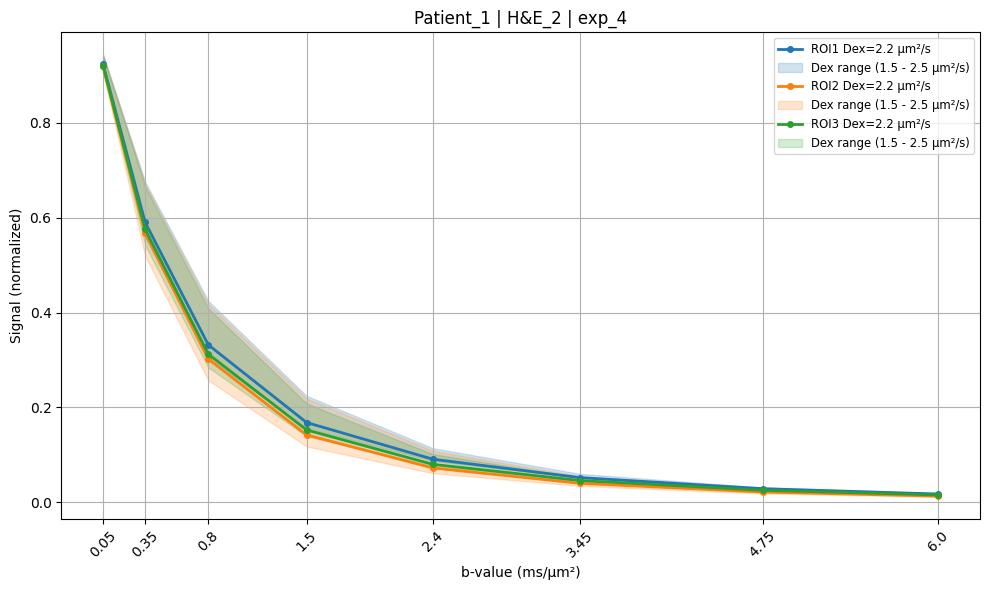

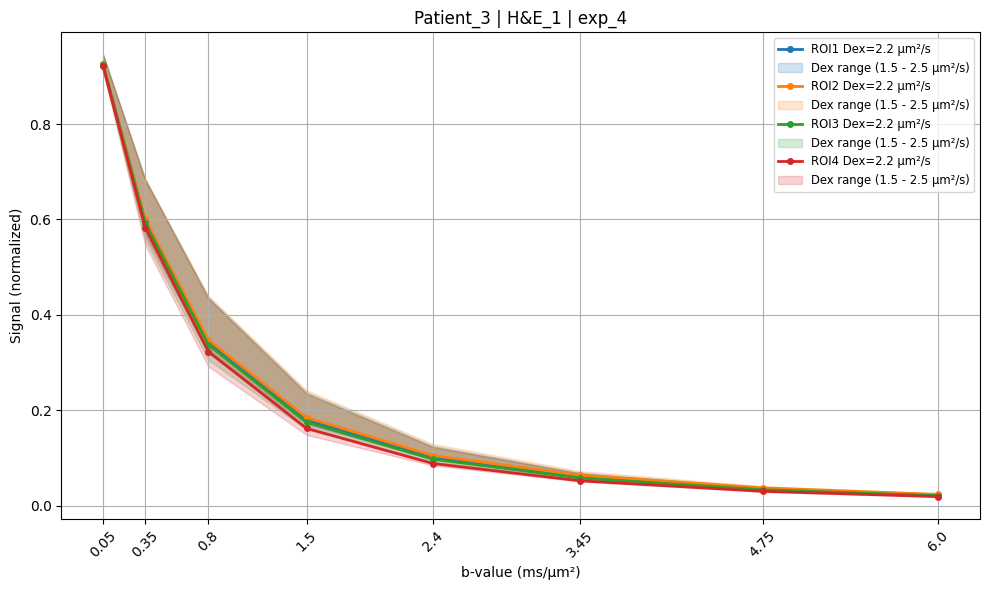

C:\Users\maely\AppData\Local\Temp\ipykernel_31572\3733838943.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')


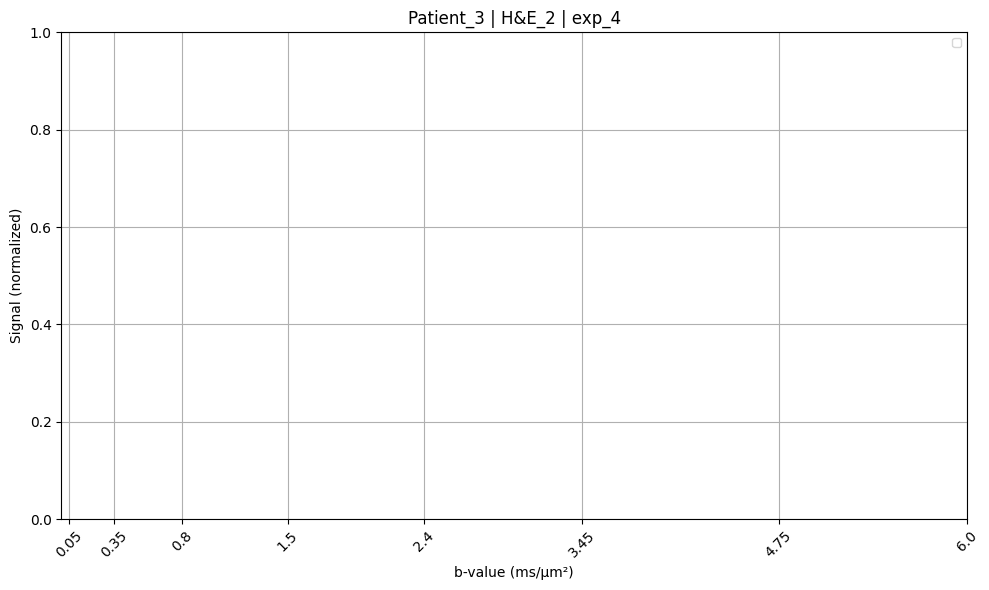

In [ ]:
exp_selected = 'exp_4'

# Dex envelope
Dex_min = 1.5
Dex_central = 2.2
Dex_max = 2.5
Dex_options = [Dex_min, Dex_central, Dex_max]

# Colors for ROIs
roi_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:cyan', 'tab:brown']

for pat_id in signal_json.keys():
    for he in signal_json[pat_id].keys():

        # New figure for each patient and H&E
        fig, ax = plt.subplots(figsize=(10,6))
        ax.set_title(f"{pat_id} | {he} | {exp_selected}")
        ax.set_xlabel("b-value (ms/µm²)")
        ax.set_ylabel("Signal (normalized)")
        ax.grid(True)

        # ROIs
        roi_names = list(signal_json[pat_id][he][exp_selected].keys())

        for idx, roi_name in enumerate(roi_names):
            color = roi_colors[idx % len(roi_colors)]

            # TD key
            TD_keys = list(signal_json[pat_id][he][exp_selected][roi_name].keys())
            TD_key = TD_keys[0]

            # Get signal
            signals = {}
            for Dex in Dex_options:
                data = signal_json[pat_id][he][exp_selected][roi_name][TD_key][f"Dex_{Dex}"]
                bvals = np.array(data['bval'])
                signals[Dex] = np.array(data['signals_mean'])

            # Central curve
            ax.plot(bvals, signals[Dex_central], color=color, linewidth=2,
                    marker='o', markersize=4,
                    label=f"{roi_name} Dex={Dex_central} µm²/s")

            # Dex
            ax.fill_between(bvals, signals[Dex_min], signals[Dex_max], color=color, alpha=0.2, label="Dex range (1.5 - 2.5 µm²/s)")

        ax.legend(fontsize='small', loc='upper right')
        ax.set_xticks(bvals)
        ax.set_xticklabels([str(b) for b in bvals], rotation=45)
        plt.tight_layout()
        plt.show()

# Exp decay : comparison between diffusion times

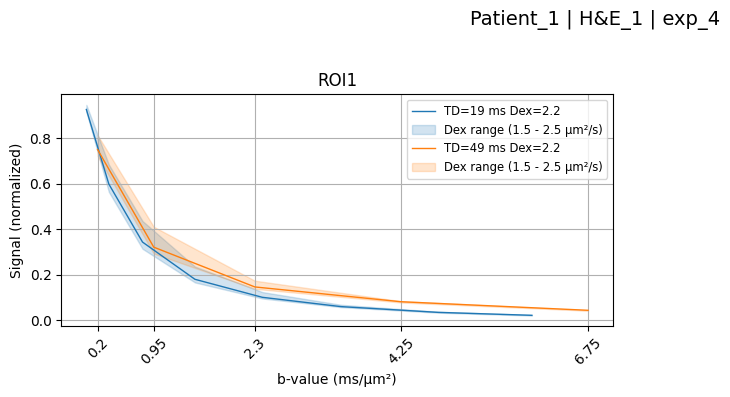

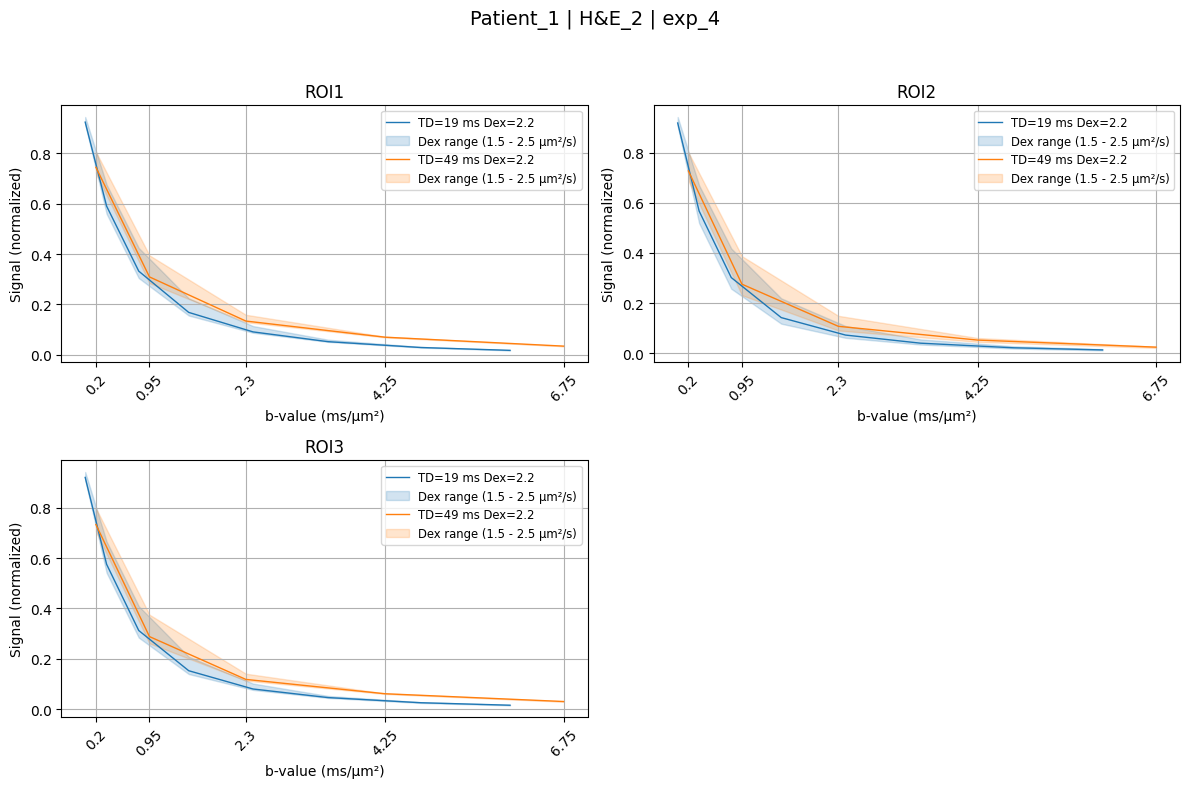

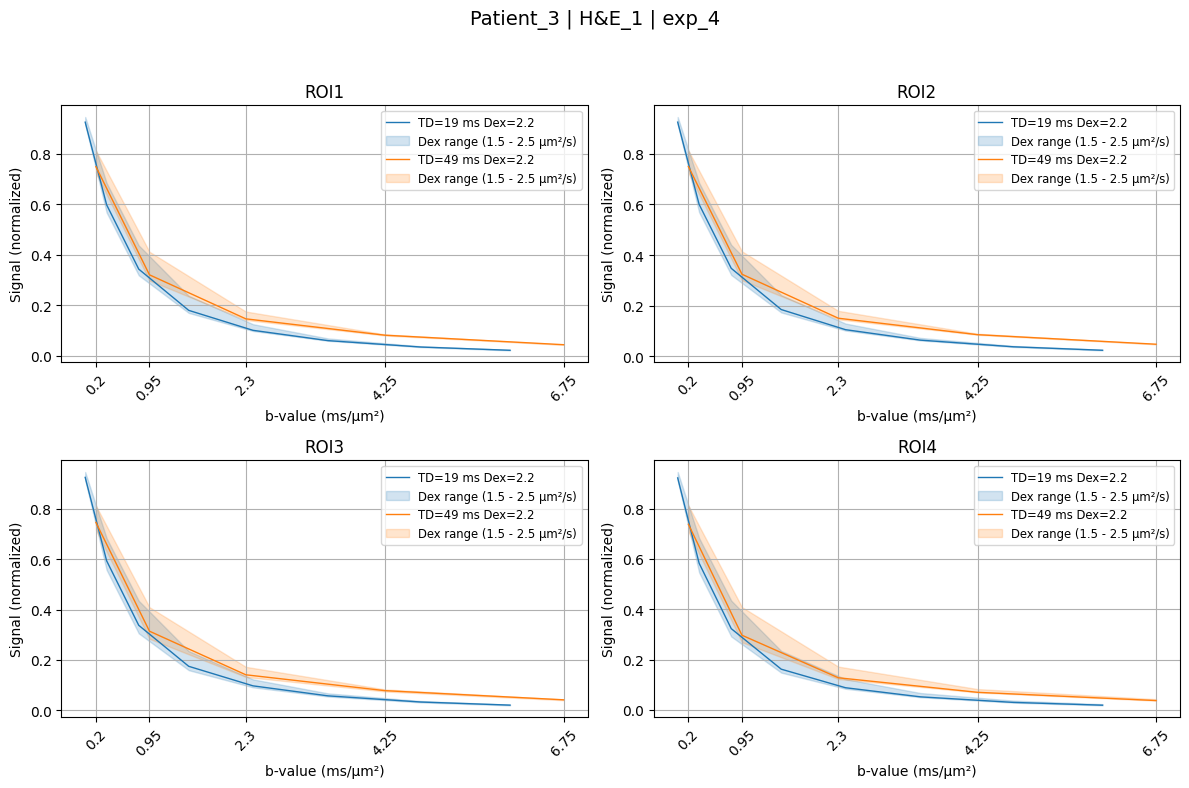

In [ ]:
exp_selected = 'exp_4'

# Dex envelope
Dex_min = 1.5
Dex_central = 2.2
Dex_max = 2.5
Dex_options = [Dex_min, Dex_central, Dex_max]

# Colors for TDs within each ROI
TD_colors = ['tab:blue', 'tab:orange']

# Colors for ROIs
roi_colors = ['tab:green', 'tab:red', 'tab:purple', 'tab:cyan', 'tab:brown']

for pat_id in signal_json.keys():
    for he in signal_json[pat_id].keys():

        # ROIs
        roi_names = list(signal_json[pat_id][he][exp_selected].keys())
        n_rois = len(roi_names)
        if n_rois == 0:
            continue

        ncols = 2
        nrows = math.ceil(n_rois / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
        axes = axes.flatten() 

        for idx, roi_name in enumerate(roi_names):
            ax = axes[idx]
            ax.set_title(f"{roi_name}")
            ax.set_xlabel("b-value (ms/µm²)")
            ax.set_ylabel("Signal (normalized)")
            ax.grid(True)

            # TD keys
            TD_keys = list(signal_json[pat_id][he][exp_selected][roi_name].keys())

            for td_idx, TD_key in enumerate(TD_keys):
                color = TD_colors[td_idx % len(TD_colors)]
                bvals = []
                signals_central = []
                signals_min = []
                signals_max = []

                for Dex in Dex_options:
                    data = signal_json[pat_id][he][exp_selected][roi_name][TD_key][f"Dex_{Dex}"]
                    bvals_all = np.array(data['bval'])
                    signal_vals_all = np.array(data['signals_mean'])

                    # Filter bvals < 7.5
                    mask = bvals_all < 7.5
                    bvals_filtered = bvals_all[mask]
                    signal_vals_filtered = signal_vals_all[mask]

                    if Dex == Dex_central:
                        signals_central = signal_vals_filtered
                        bvals = bvals_filtered
                    elif Dex <= Dex_min:
                        signals_min = signal_vals_filtered
                    elif Dex >= Dex_max:
                        signals_max = signal_vals_filtered

                # Central curve
                ax.plot(bvals, signals_central, color=color, linewidth=1,
                        label=f"TD={TD_key.split('_')[1]} ms Dex={Dex_central}")

                # Dex envelope
                if len(signals_min) > 0 and len(signals_max) > 0:
                    ax.fill_between(bvals, signals_min, signals_max, color=color, alpha=0.2, label="Dex range (1.5 - 2.5 µm²/s)")

            ax.legend(fontsize='small')
            ax.set_xticks(bvals)
            ax.set_xticklabels([str(b) for b in bvals], rotation=45)

        for j in range(n_rois, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f"{pat_id} | {he} | {exp_selected}", fontsize=14)
        plt.tight_layout(rect=[0,0,1,0.95])
        plt.show()

# Exponential decay for each patient

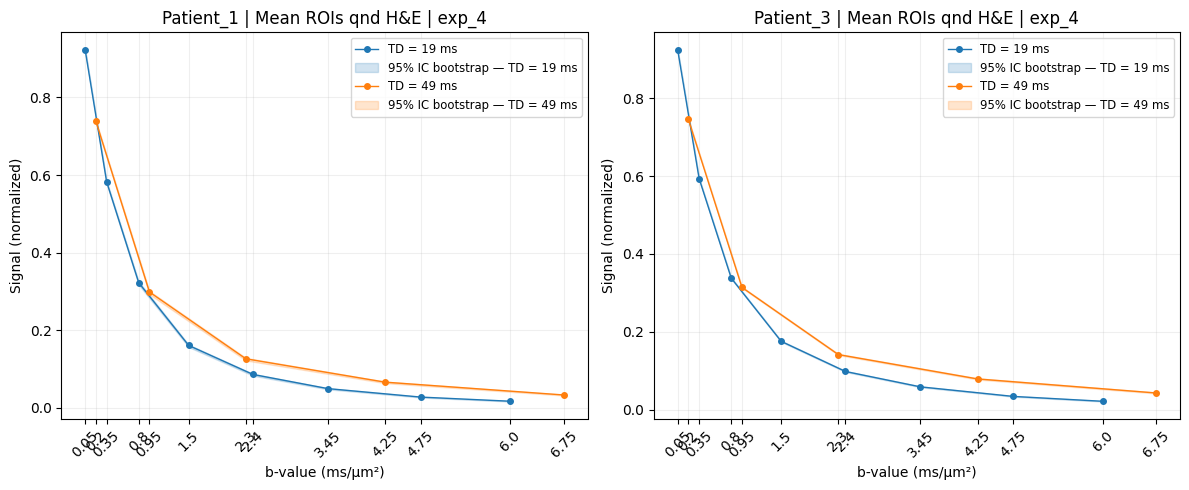

In [ ]:
exp_selected = "exp_4"
Dex_central  = 2.2
bval_max     = 7.5
TD_colors    = ['tab:blue', 'tab:orange']

pat_ids = list(signal_json.keys())
n_pats  = len(pat_ids)

ncols = min(2, n_pats)
nrows = int(np.ceil(n_pats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = np.array(axes).flatten()

for ax_idx, pat_id in enumerate(pat_ids):
    ax = axes[ax_idx]

    td_bval_signals = {}
    all_bvals = set()

    for he in signal_json[pat_id].keys():
        if exp_selected not in signal_json[pat_id][he]:
            continue
        for roi_name in signal_json[pat_id][he][exp_selected].keys():
            for TD_key in signal_json[pat_id][he][exp_selected][roi_name].keys():
                if TD_key not in td_bval_signals:
                    td_bval_signals[TD_key] = {}

                data   = signal_json[pat_id][he][exp_selected][roi_name][TD_key][f"Dex_{Dex_central}"]
                bvals   = np.array(data["bval"])
                signals = np.array(data["signals_mean"])
                p_lows  = np.array(data["p_low"])
                p_highs = np.array(data["p_high"])

                mask    = bvals < bval_max
                bvals, signals = bvals[mask], signals[mask]
                p_lows, p_highs = p_lows[mask], p_highs[mask]

                all_bvals.update(bvals.tolist())

                for b, s, pl, ph in zip(bvals, signals, p_lows, p_highs):
                    td_bval_signals[TD_key].setdefault(b, {
                        "signals": [], "p_lows": [], "p_highs": []
                    })
                    td_bval_signals[TD_key][b]["signals"].append(s)
                    td_bval_signals[TD_key][b]["p_lows"].append(pl)
                    td_bval_signals[TD_key][b]["p_highs"].append(ph)

    all_bvals = sorted(all_bvals)

    for td_idx, TD_key in enumerate(sorted(td_bval_signals.keys())):
        bvals_sorted = sorted(td_bval_signals[TD_key].keys())

        mean_signals, p_lows_agg, p_highs_agg, bvals_used = [], [], [], []

        for b in bvals_sorted:
            entry = td_bval_signals[TD_key][b]
            if len(entry["signals"]) > 0:
                mean_signals.append(np.mean(entry["signals"]))
                p_lows_agg.append(np.mean(entry["p_lows"]))
                p_highs_agg.append(np.mean(entry["p_highs"]))
                bvals_used.append(b)

        mean_signals = np.array(mean_signals)
        p_lows_agg   = np.array(p_lows_agg)
        p_highs_agg  = np.array(p_highs_agg)
        bvals_used   = np.array(bvals_used)

        color    = TD_colors[td_idx % len(TD_colors)]
        td_label = TD_key.split('_')[1]

        ax.plot(bvals_used, mean_signals, marker='o', markersize=4,
                linewidth=1, color=color,
                label=f"TD = {td_label} ms")
        ax.fill_between(bvals_used, p_lows_agg, p_highs_agg,
                        color=color, alpha=0.2,
                        label=f"95% CI bootstrap — TD = {td_label} ms")
    ax.set_title(f"{pat_id} | Mean ROIs and H&E | {exp_selected}")
    ax.set_xlabel("b-value (ms/µm²)")
    ax.set_ylabel("Signal (normalized)")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize='small')
    ax.set_xticks(all_bvals)
    ax.set_xticklabels([str(round(b, 2)) for b in all_bvals], rotation=45)

for j in range(len(pat_ids), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Check bootstrap

b-value | mean   | p_low  | p_high | largeur IC
0.050   | 0.9253 | 0.9253 | 0.9254 | 0.0001
0.350   | 0.5981 | 0.5978 | 0.5988 | 0.0010
0.800   | 0.3431 | 0.3425 | 0.3442 | 0.0017
1.500   | 0.1797 | 0.1789 | 0.1808 | 0.0019
2.400   | 0.1007 | 0.0999 | 0.1016 | 0.0017
3.450   | 0.0598 | 0.0592 | 0.0604 | 0.0011
4.750   | 0.0345 | 0.0341 | 0.0349 | 0.0009
6.000   | 0.0216 | 0.0213 | 0.0219 | 0.0006


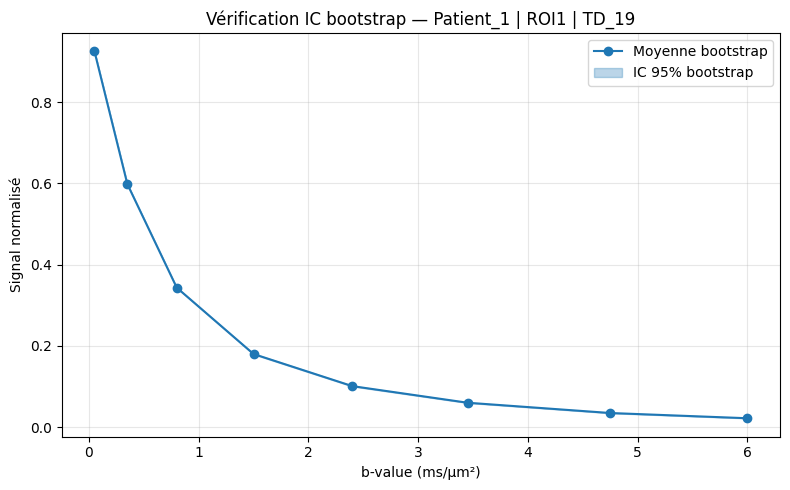

In [ ]:
# Check on a single ROI
pat_id   = "Patient_1"
he       = "H&E_1"
exp      = "exp_4"
roi_name = "ROI1"
TD_key   = "TD_19"
Dex_key  = "Dex_2.2"

data = signal_json[pat_id][he][exp][roi_name][TD_key][Dex_key]

bvals   = np.array(data["bval"])
signals = np.array(data["signals_mean"])
p_lows  = np.array(data["p_low"])
p_highs = np.array(data["p_high"])

# Print to inspect raw values
print("b-value | mean   | p_low  | p_high | CI width")
for b, s, pl, ph in zip(bvals, signals, p_lows, p_highs):
    print(f"{b:.3f}   | {s:.4f} | {pl:.4f} | {ph:.4f} | {ph-pl:.4f}")

# Plot on this single ROI
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bvals, signals, 'o-', color='tab:blue', label='Bootstrap mean')
ax.fill_between(bvals, p_lows, p_highs, alpha=0.3, color='tab:blue',
                label='Bootstrap 95% CI')
ax.set_xlabel("b-value (ms/µm²)")
ax.set_ylabel("Normalized signal")
ax.set_title(f"Bootstrap CI check — {pat_id} | {roi_name} | {TD_key}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# All std (ROIs + parameters)

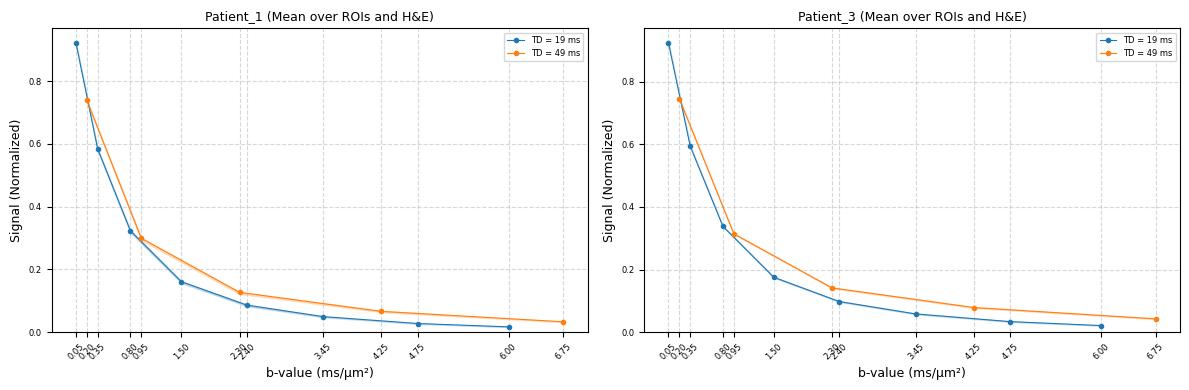

In [ ]:
exp_selected = "exp_4"
Dex_central = 2.2
bval_max = 7.5
TD_colors = ['tab:blue', 'tab:orange']

pat_ids = list(signal_json.keys())
n_pats = len(pat_ids)

ncols = min(2, n_pats)  
nrows = int(np.ceil(n_pats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).flatten()  

for ax_idx, pat_id in enumerate(pat_ids):
    ax = axes[ax_idx]

    td_bval_agg = {}
    all_bvals = set()

    for he in signal_json[pat_id].keys():
        if exp_selected not in signal_json[pat_id][he]:
            continue
            
        for roi_name in signal_json[pat_id][he][exp_selected].keys():
            roi_data = signal_json[pat_id][he][exp_selected][roi_name]
            
            for TD_key in roi_data.keys():
                if TD_key not in td_bval_agg:
                    td_bval_agg[TD_key] = {}

                dex_key = f"Dex_{Dex_central}"
                if dex_key not in roi_data[TD_key]:
                    continue
                    
                data = roi_data[TD_key][dex_key]
                bvals = np.array(data["bval"])
                signals = np.array(data["signals_median"])
                p_lows = np.array(data["p_low"])
                p_highs = np.array(data["p_high"])

                # Max b-value filtering
                mask = bvals < bval_max
                all_bvals.update(bvals[mask].tolist())

                # Aggregation
                for b, s, low, high in zip(bvals[mask], signals[mask], p_lows[mask], p_highs[mask]):
                    if b not in td_bval_agg[TD_key]:
                        td_bval_agg[TD_key][b] = {'s_vals': [], 'low_vals': [], 'high_vals': []}
                    td_bval_agg[TD_key][b]['s_vals'].append(s)
                    td_bval_agg[TD_key][b]['low_vals'].append(low)
                    td_bval_agg[TD_key][b]['high_vals'].append(high)

    all_bvals_sorted = sorted(list(all_bvals))

    # Plot for each TD with aggregated mean and uncertainty
    for td_idx, TD_key in enumerate(sorted(td_bval_agg.keys())):
        bvals_plot = sorted(td_bval_agg[TD_key].keys())
        final_medians = [np.mean(td_bval_agg[TD_key][b]['s_vals']) for b in bvals_plot]
        final_lows = [np.mean(td_bval_agg[TD_key][b]['low_vals']) for b in bvals_plot]
        final_highs = [np.mean(td_bval_agg[TD_key][b]['high_vals']) for b in bvals_plot]

        color = TD_colors[td_idx % len(TD_colors)]
        label = f"TD = {TD_key.split('_')[1]} ms"

        ax.plot(bvals_plot, final_medians, marker='o', markersize=3, color=color,
                label=label, linewidth=0.8)
        ax.fill_between(bvals_plot, final_lows, final_highs, color=color, alpha=0.2)

    ax.set_title(f"{pat_id} (Mean over ROIs and H&E)", fontsize=9)
    ax.set_xlabel("b-value (ms/µm²)", fontsize=9)
    ax.set_ylabel("Signal (Normalized)", fontsize=9)
    ax.set_ylim(bottom=0)
    ax.set_xticks(all_bvals_sorted)
    ax.set_xticklabels([f"{x:.2f}" for x in all_bvals_sorted], rotation=45)
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.tick_params(axis='both', which='minor', labelsize=5)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(fontsize=6)

for j in range(len(pat_ids), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()